#### Gaussian Mixture Model
This notebook implements and evaluates a Guassian Mixture Model to soft-cluster Axle load data obtained from NYC WIM datasets

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Capstone_Data") \
    .master("local[*]") \
    .getOrCreate()


In [3]:
#historical dataset 2019 - 2023
df = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_19_23.csv", header=True, inferSchema=True)

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\rubie\AppData\Local\Temp\ipykernel_2180\3529866632.py:2: SyntaxWarning: invalid escape sequence '\R'
  df = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_19_23.csv", header=True, inferSchema=True)


In [4]:
df2 = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_24_25.csv", header=True, inferSchema=True)

<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:1: SyntaxWarning: invalid escape sequence '\R'
C:\Users\rubie\AppData\Local\Temp\ipykernel_2180\3059976666.py:1: SyntaxWarning: invalid escape sequence '\R'
  df2 = spark.read.csv("Data\Raw_Data\Weigh_in_Motion_24_25.csv", header=True, inferSchema=True)


In [5]:
#aggregating both datasets into 1
df3 = df.union(df2)

In [6]:
#Creating a date column
from pyspark.sql.functions import col, concat, lpad
df4 = df3.withColumn(
    "date",
    concat(
        col("year"),
        lpad(col("month"), 2, "0"),  
        lpad(col("day"), 2, "0")
    )
)


In [7]:
#Filtering for QueensBound Data and casting gvw column as float type
from pyspark.sql import functions as F

df5 = df4.filter("direction = 'QB'").withColumn("gvw", F.col("gvw").cast("float"))

In [8]:
df5 = df5.fillna(0)

In [9]:
# Removing outliers *asssume pandas df, targets gvw col
#Outliers are removed using vehicle gvw 
def remove_outliers_iqr(df, factor):
    Q1 = df["gvw"].quantile(0.25)
    Q3 = df["gvw"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    outliers_iqr = df[(df["gvw"] < lower_bound) | (df["gvw"] > upper_bound)]
    
    print(f"Outlier Count: {len(outliers_iqr)}")
    print(f"Original Count: {len(df)}")
    print(f"Remaining count: {len(df) - len(outliers_iqr)}")
    print(f"Outlier percentage: {len(outliers_iqr)/len(df)*100:.2f}%")
    print(f"Upper bound: {upper_bound:.2f}, Lower bound: {lower_bound:.2f}")
    
    # Return filtered dataframe
    return df[(df["gvw"] >= lower_bound) & (df["gvw"] <= upper_bound)], upper_bound, lower_bound

In [10]:
#eliminate outliers from spark df
#Outliers are removed using vehicle gvw 
from pyspark.sql import functions as F

def remove_outliers_iqr2(df_spark, factor):
    # Step 1: Get Q1 and Q3
    q1, q3 = df_spark.approxQuantile("gvw", [0.25, 0.75], 0.01)

    # Step 2: Compute IQR
    iqr = q3 - q1

    # Step 3: Define bounds
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr

    print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

    # Step 4: Filter outliers
    return df_spark.filter((F.col("gvw") >= lower_bound) & (F.col("gvw") <= upper_bound)) , upper_bound, lower_bound

In [11]:
#Gaussian Model
from sklearn.mixture import GaussianMixture as GM

def fit_gaussian_model_pandas(data, cols, n_components, n_init=1, max_iter=100):
    input = data[cols]
    model = GM(n_components=n_components, n_init=n_init, max_iter=max_iter).fit(input)

    return model.aic(input)


In [12]:
#Function for Model Paramter Tuning
#For returns AIC criterion result for GMM with 1, 2, 3 components
def tune_parameter(data, cols, n_init, max_iter):
    aic_1 = fit_gaussian_model_pandas(data, cols, 1, n_init, max_iter)
    aic_2 = fit_gaussian_model_pandas(data, cols, 2, n_init, max_iter)
    aic_3 = fit_gaussian_model_pandas(data, cols, 3, n_init, max_iter)

    return aic_1, aic_2, aic_3

In [13]:
#find sample mean
import gc

def find_sample_mean(spark_df, pop_mean, sample_size, total_spark_df_cnt):
    
    fraction = min(1.0,(sample_size / total_spark_df_cnt))
    
    df_sample = spark_df.select("gvw").sample(
    withReplacement=False,  
    fraction=fraction               
    ).limit(sample_size).toPandas()

    bias = pop_mean - df_sample["gvw"].mean()

    del df_sample
    gc.collect()

    return bias, sample_size



In [23]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import GaussianMixture as spark_GM

def fit_gmm_spark(df_spark, cols, num_clusters, max_iter):
    
    assembler = VectorAssembler(inputCols=cols, outputCol="features")
    df_input = assembler.transform(df_spark)

    gmm = spark_GM(k=num_clusters, maxIter=max_iter)

    # Fit the model
    model = gmm.fit(df_input)

    return model


### Class 2

In [15]:
import pandas as pd
#filtering by class
class_num = 2
sample_ratio = .01
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.6
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 6664.0, Lower bound: 196.0


In [14]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [ ]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


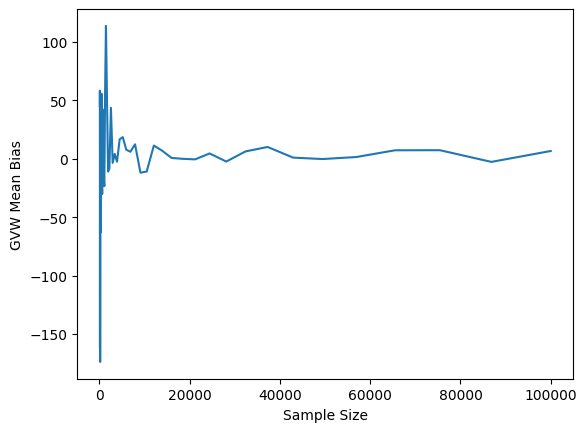

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [15]:
#Sub-sample for model parameter tuning
sample_size = 20000
tuning_sample_df = df_sample.sample(sample_size)

In [28]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    3.3s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    6.9s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   13.7s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   28.5s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:   58.5s
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  2.3min remaining:   53.1s
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  3.9min remaining:   48.8s
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  5.9min remaining:   25.0s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed:  7.0min finished


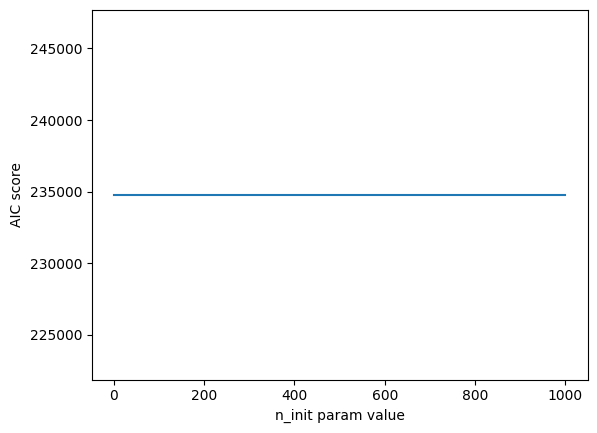

In [29]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

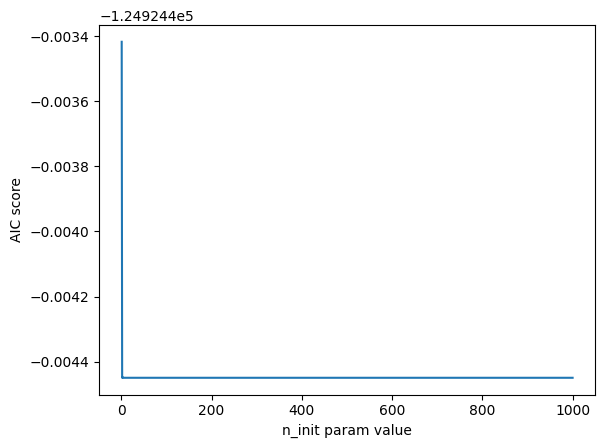

In [30]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

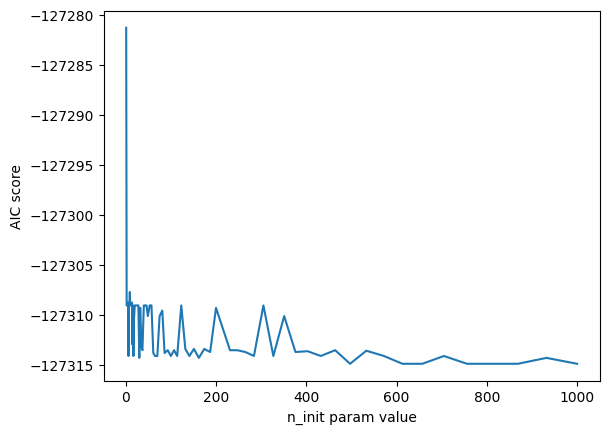

In [31]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [63]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.19217324256896973s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    0.6s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    1.2s
[Parallel(n_jobs=15)]: Done  32 tasks      | elapsed:    2.6s
[Parallel(n_jobs=15)]: Batch computation too slow (2.478907346725464s.) Setting batch_size=1.
[Parallel(n_jobs=15)]: Done  60 out of 100 | elapsed:    3.3s remaining:    2.2s
[Parallel(n_jobs=15)]: Done  82 out of 100 | elapsed:    5.0s remaining:    1.0s
[Parallel(n_jobs=15)]: Done  93 out of 100 | elapsed:    5.4s remaining:    0.3s
[Parallel(n_jobs=15)]: Done 100 out of 100 | elapsed:    5.6s finished


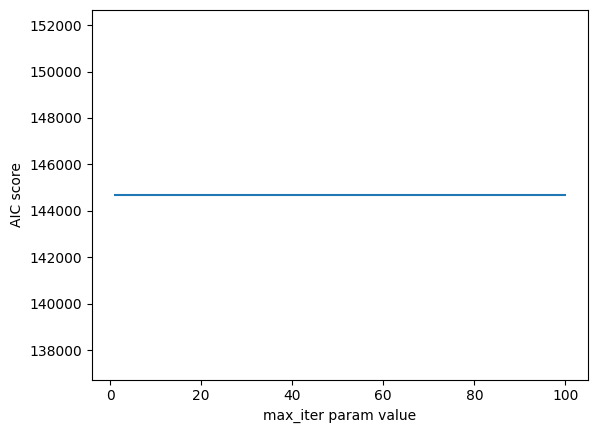

In [64]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

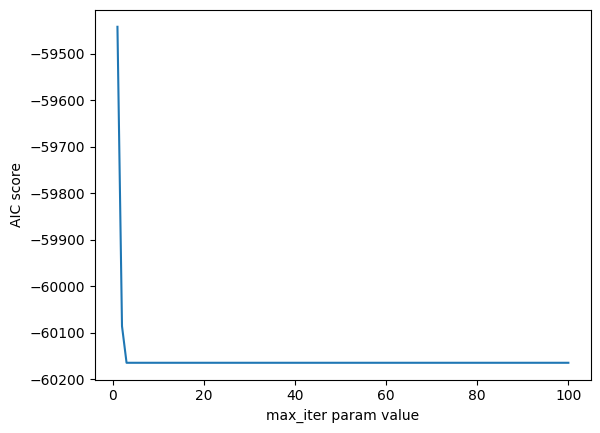

In [65]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

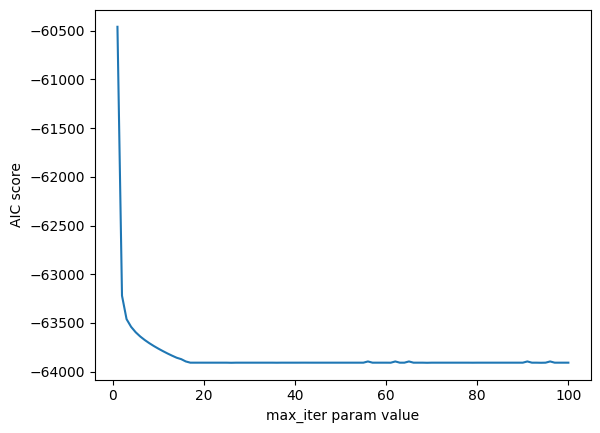

In [66]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [ ]:
#Class 2 Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 100
max_iter : 10

Clusters 2:
n_init : 100
max_iter : 10

Clusters 3:
n_init : 10  * modified because run time was too long with original 200, error tradeoff is not significant

max_iter : 20

"""

In [33]:
#cluster 1
#Computing mean of sample means of AIC score 

num_of_sample_means = 100
num_of_trials_in_sample_mean = 100
sample_size = 20000
cluster_num = 1
n_init = 100
max_iter = 10

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [34]:
#cluster 2
#Computing mean of sample means of AIC score 

num_of_sample_means = 100
num_of_trials_in_sample_mean = 100
sample_size = 20000
cluster_num = 2
n_init = 100
max_iter = 10

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [41]:
#cluster 3
#Computing mean of sample means of AIC score 

num_of_sample_means = 100
num_of_trials_in_sample_mean = 100
sample_size = 20000

cluster_num = 3
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [ ]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 252297.65727417503
Cluster=1 var: 0.0
Cluster=2 mean: -133641.7600624543
Cluster=2 var: 8.470329472543003e-22
Mean difference: 385939.41733662935
T-statistic: 1.3194306924824341e+17
P-value: 0.0


In [45]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 252297.65727417503
Cluster=1 var: 0.0
Cluster=3 mean: -137779.12869672687
Cluster=3 var: 0.006380524846376943
Mean difference: 390076.7859709019
T-statistic: 48589172.26957199
P-value: 0.0


In [46]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: -133641.7600624543
Cluster=2 var: 8.470329472543003e-22
Cluster=3 mean: -137779.12869672687
Cluster=3 var: 0.006380524846376943
Mean difference: 4137.3686342725705
T-statistic: 515363.4477709981
P-value: 0.0


Class 3

In [13]:
import pandas as pd
#filtering by class
class_num = 3
sample_ratio = .01
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 2.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 12790.0, Lower bound: -1970.0


In [ ]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


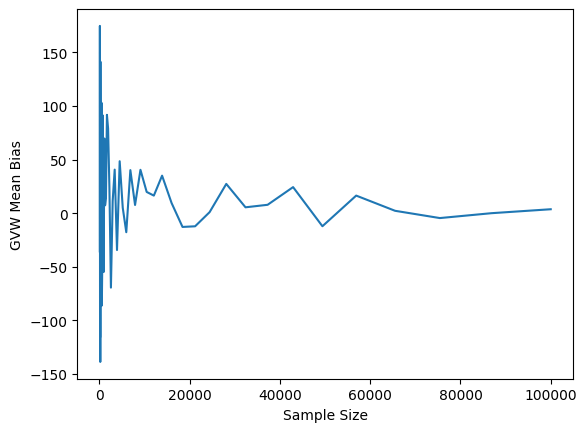

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [ ]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [ ]:
#Sub-sample for model parameter tuning
sample_size = 20000
tuning_sample_df = df_sample.sample(sample_size)

In [ ]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    3.1s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    5.7s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   10.0s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   19.6s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:   41.6s
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  1.5min remaining:   35.5s
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  2.8min remaining:   34.8s
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  3.9min remaining:   16.8s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed:  4.8min finished


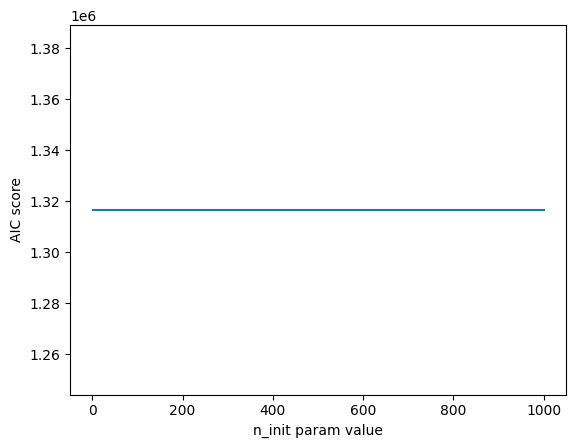

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

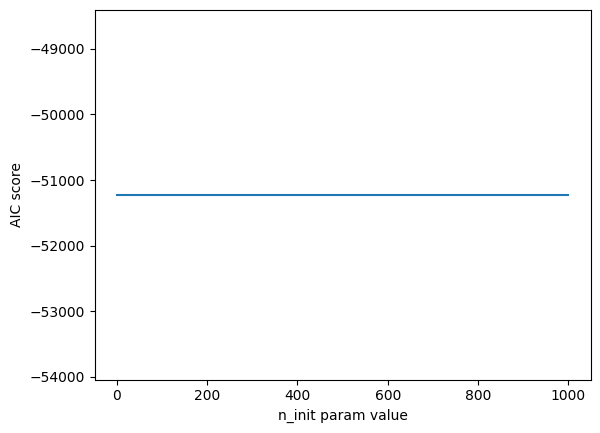

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

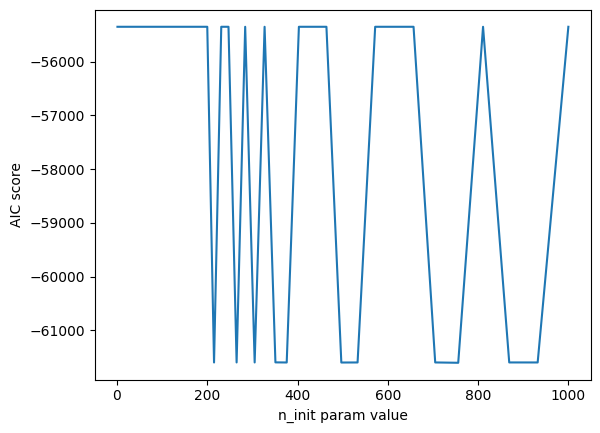

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [22]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    0.6s remaining:    1.6s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    0.7s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    0.7s finished


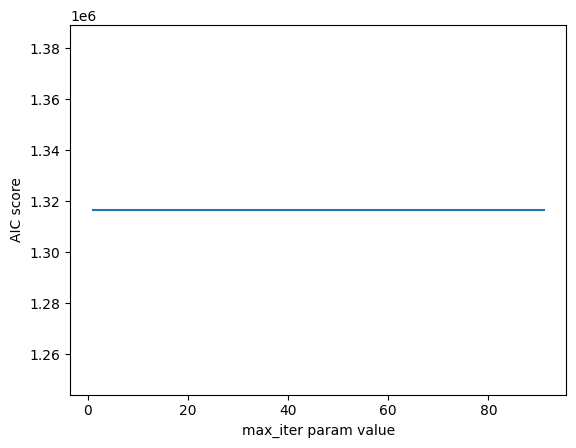

In [23]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

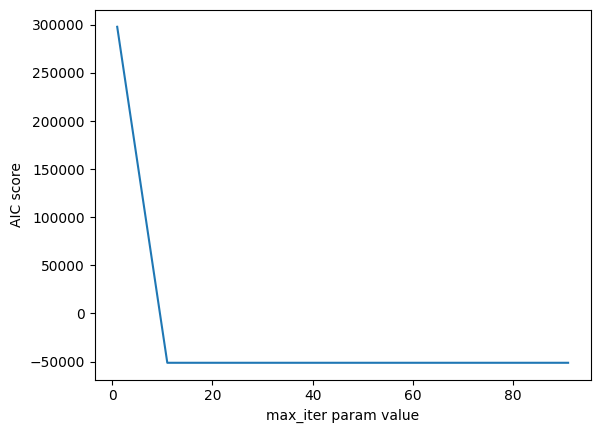

In [24]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

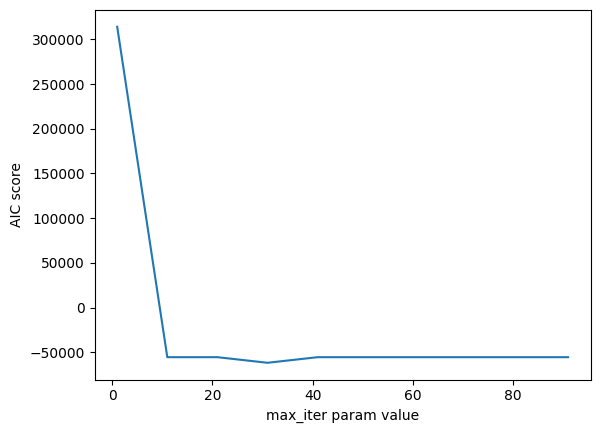

In [25]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [ ]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

In [21]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [22]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [23]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [24]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 890693.1128898597
Cluster=1 var: 1.3552527156068805e-20
Cluster=2 mean: -65467.59093143671
Cluster=2 var: 0.00282967608234828
Mean difference: 956160.7038212965
T-statistic: 178846368.620283
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [25]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 890693.1128898597
Cluster=1 var: 1.3552527156068805e-20
Cluster=3 mean: -74250.41634894823
Cluster=3 var: 0.019037417216826457
Mean difference: 964943.529238808
T-statistic: 69584975.95943217
P-value: 0.0


In [26]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: -65467.59093143671
Cluster=2 var: 0.00282967608234828
Cluster=3 mean: -74250.41634894823
Cluster=3 var: 0.019037417216826457
Mean difference: 8782.825417511522
T-statistic: 590957.5947353467
P-value: 0.0


Class 4

In [20]:
import pandas as pd
#filtering by class
class_num = 4
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.3
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 63208.0, Lower bound: -9368.0


In [ ]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


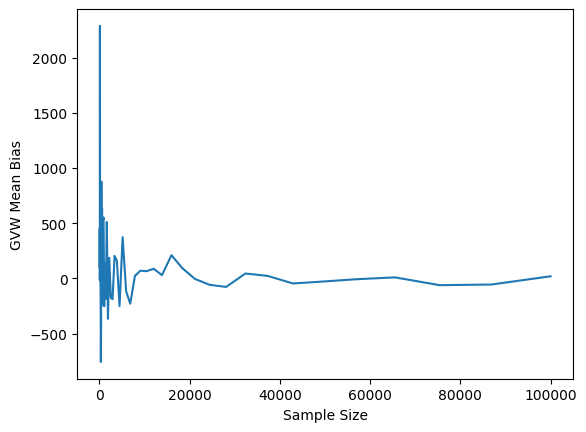

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [ ]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [ ]:
#Sub-sample for model parameter tuning
sample_size = 20000
tuning_sample_df = df_sample.sample(sample_size)

In [ ]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    3.3s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    6.0s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   11.0s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   22.3s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:   46.3s
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  1.9min remaining:   43.4s
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  3.1min remaining:   38.6s
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  4.4min remaining:   19.0s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed:  5.0min finished


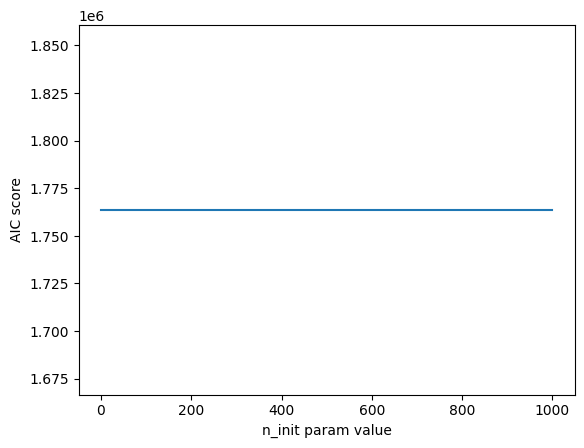

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

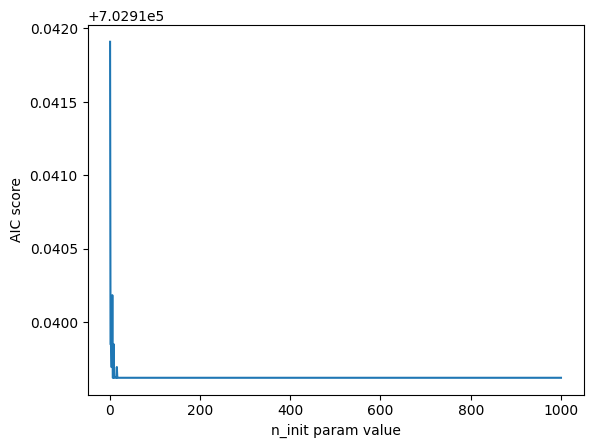

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

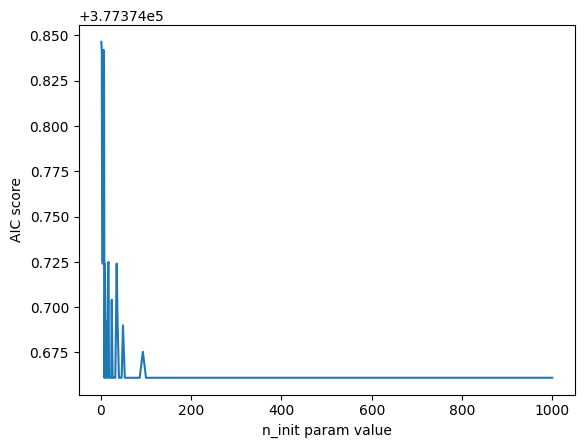

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [ ]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    0.7s remaining:    1.8s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    0.7s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    0.9s finished


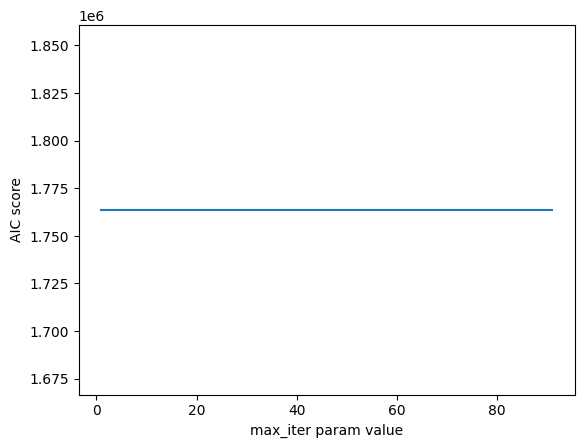

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

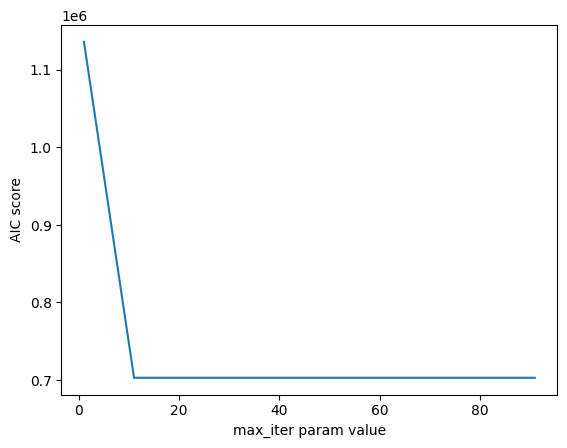

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

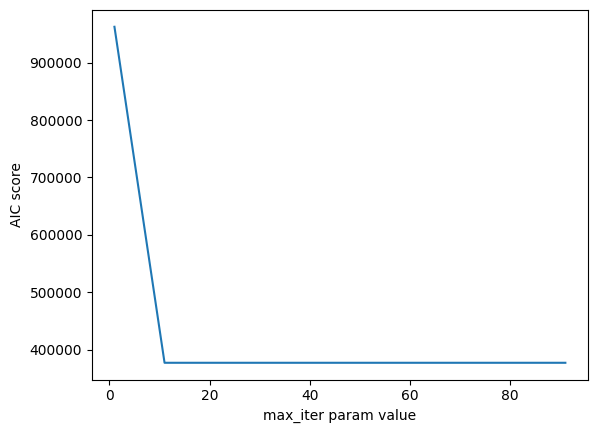

In [41]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [ ]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

In [ ]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

In [21]:
import numpy as np
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [22]:
print(f"Mean: {np.mean(n2_sample_means)}, Var: {np.var(n2_sample_means)}")

Mean: 363061.342860753, Var: 0.0


In [ ]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [ ]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 704432.2621444272
Cluster=1 var: 0.0
Cluster=2 mean: 363061.342860753
Cluster=2 var: 0.0
Mean difference: 341370.91928367416
T-statistic: inf
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 704432.2621444272
Cluster=1 var: 0.0
Cluster=3 mean: 350555.96173252823
Cluster=3 var: 275.66398227658715
Mean difference: 353876.30041189893
T-statistic: 212069.91520826155
P-value: 0.0


In [ ]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 363061.342860753
Cluster=2 var: 0.0
Cluster=3 mean: 350555.96173252823
Cluster=3 var: 275.66398227658715
Mean difference: 12505.381128224777
T-statistic: 7494.186845580716
P-value: 0.0


Class 5

In [16]:
import pandas as pd
#filtering by class
class_num = 5
sample_ratio = .01
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.6
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 44052.0, Lower bound: -9162.0


In [49]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


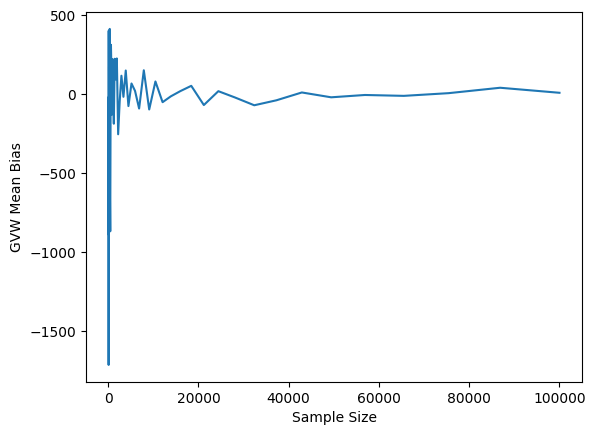

In [50]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [51]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [52]:
#Sub-sample for model parameter tuning
sample_size = 20000
tuning_sample_df = df_sample.sample(sample_size)

In [53]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    3.4s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    6.5s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   11.8s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   24.7s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:   57.9s
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  2.5min remaining:   58.4s
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  3.8min remaining:   48.2s
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  5.3min remaining:   22.6s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed:  6.0min finished


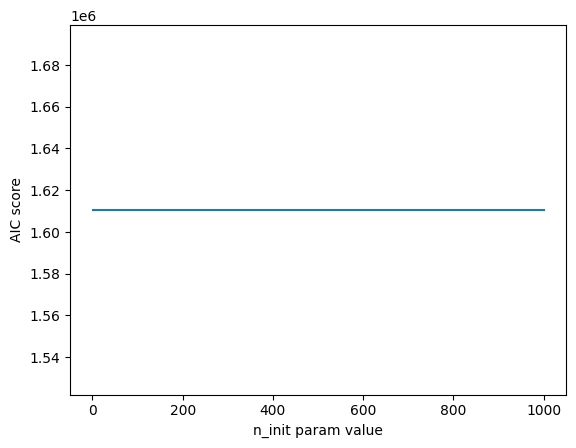

In [54]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

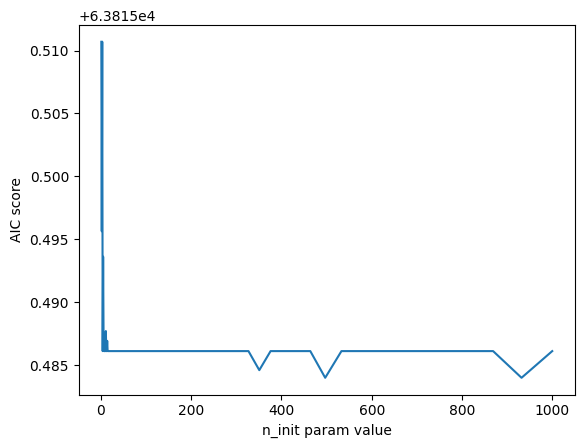

In [55]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

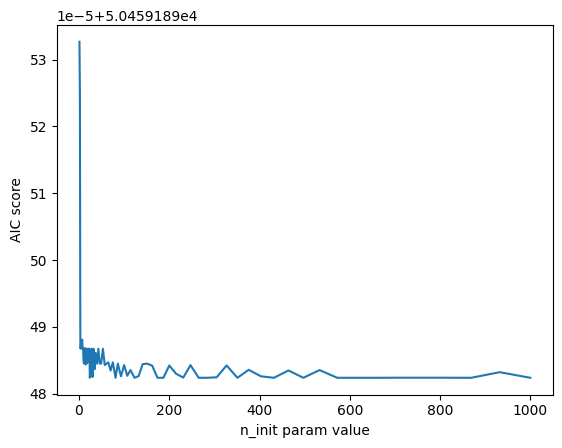

In [56]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [57]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    0.7s remaining:    1.8s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    0.7s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    0.8s finished


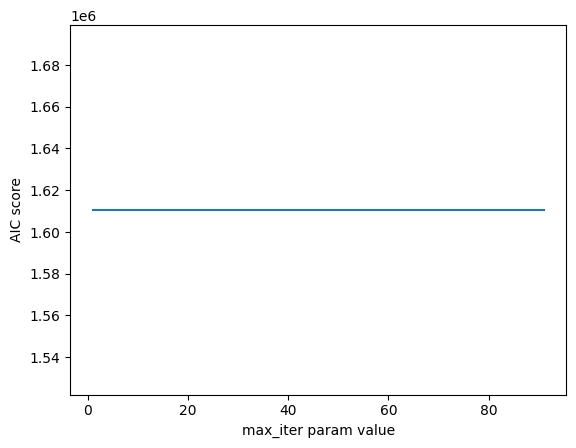

In [58]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

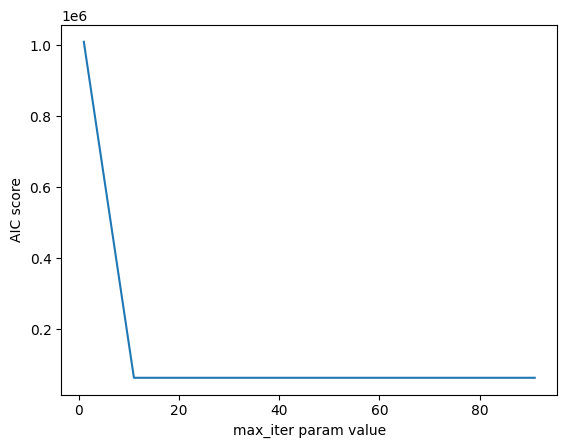

In [59]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

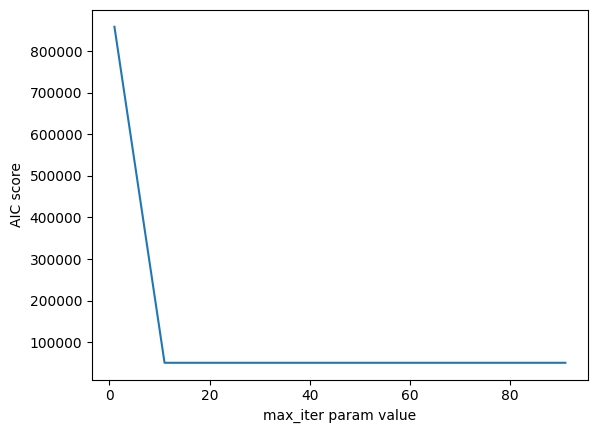

In [60]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [61]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [62]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [18]:
import numpy as np
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [19]:
print(f"Mean: {np.mean(n2_sample_means)}, Var: {np.var(n2_sample_means)}")

Mean: 609517.1718598986, Var: 0.0


In [64]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [65]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1597213.7008804188
Cluster=1 var: 5.421010862427522e-20
Cluster=2 mean: 609517.1718598986
Cluster=2 var: 0.0
Mean difference: 987696.5290205202
T-statistic: 4.220860375708103e+16
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [66]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1597213.7008804188
Cluster=1 var: 5.421010862427522e-20
Cluster=3 mean: 54845.59653524777
Cluster=3 var: 1.901935053871999e-14
Mean difference: 1542368.104345171
T-statistic: 111277451949285.98
P-value: 0.0


In [67]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 609517.1718598986
Cluster=2 var: 0.0
Cluster=3 mean: 54845.59653524777
Cluster=3 var: 1.901935053871999e-14
Mean difference: 554671.5753246509
T-statistic: 40018026409778.37
P-value: 0.0


Class 6

In [68]:
import pandas as pd
#filtering by class
class_num = 6
sample_ratio = .01
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.6
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 74704.0, Lower bound: -2534.0


In [69]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


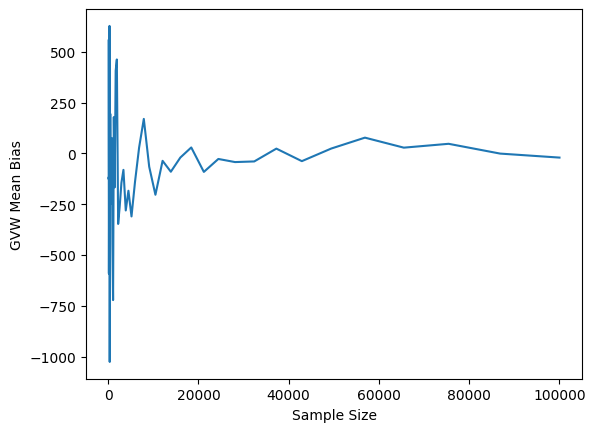

In [70]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [71]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [74]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [75]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    2.9s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    4.1s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    5.8s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   10.2s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:   20.5s
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:   47.7s remaining:   18.5s
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  1.4min remaining:   17.4s
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  2.0min remaining:    8.6s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed:  2.5min finished


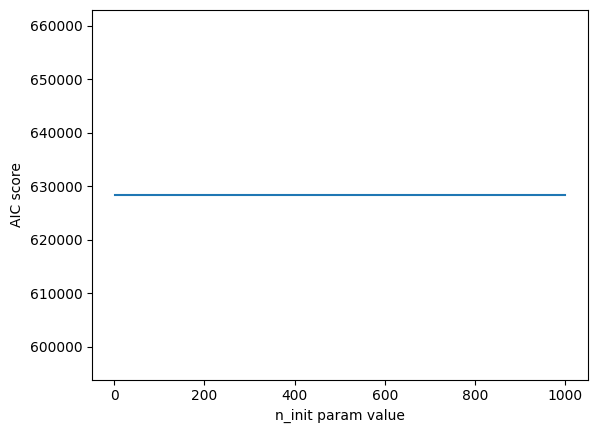

In [76]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

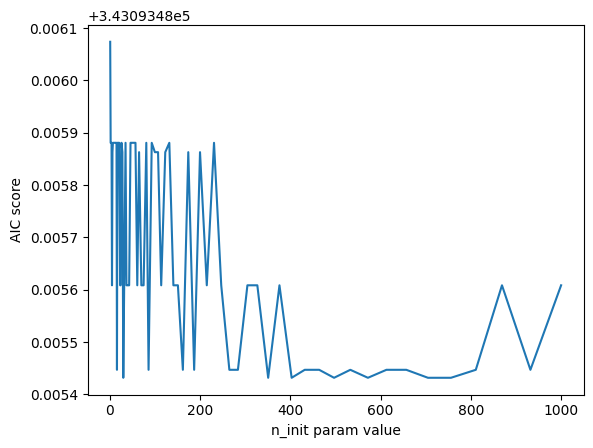

In [77]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

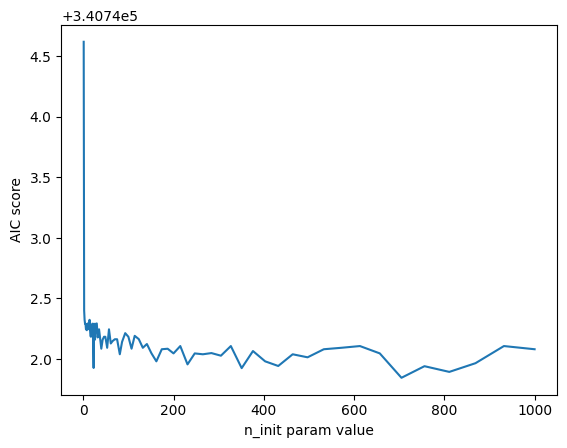

In [78]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [79]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.17382097244262695s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    0.3s remaining:    0.9s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    0.3s remaining:    0.3s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    0.4s finished


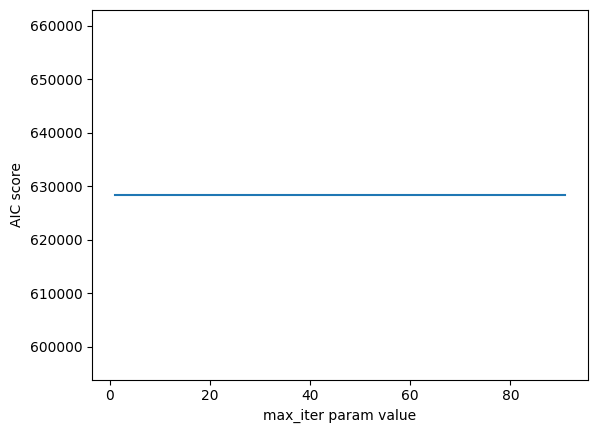

In [80]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

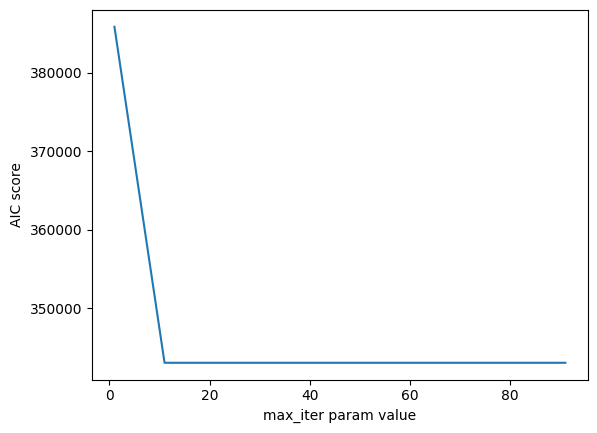

In [81]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

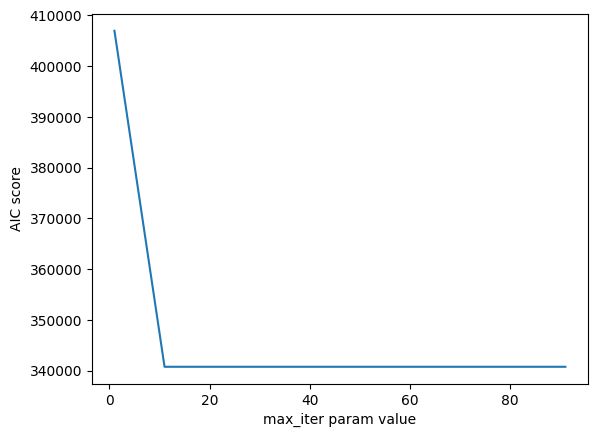

In [82]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [ ]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

In [83]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [84]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [85]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [86]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 644655.169117652
Cluster=1 var: 0.0
Cluster=2 mean: 631737.1941575955
Cluster=2 var: 0.0014371693658185233
Mean difference: 12917.974960056483
T-statistic: 3390455.5889563514
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [87]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 644655.169117652
Cluster=1 var: 0.0
Cluster=3 mean: 628253.6952008766
Cluster=3 var: 0.0011880307203326846
Mean difference: 16401.47391677543
T-statistic: 4734636.474709367
P-value: 0.0


In [88]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 631737.1941575955
Cluster=2 var: 0.0014371693658185233
Cluster=3 mean: 628253.6952008766
Cluster=3 var: 0.0011880307203326846
Mean difference: 3483.4989567189477
T-statistic: 676475.5075755876
P-value: 0.0


Class 7

In [89]:
import pandas as pd
#filtering by class
class_num = 7
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 8)] #Max number of axles determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 115145.0, Lower bound: -1535.0


In [94]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


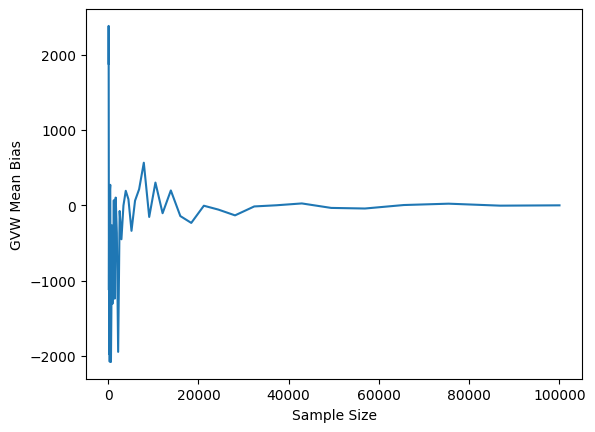

In [95]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [96]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [97]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [98]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    4.3s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:   10.4s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   20.8s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   45.2s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:  1.6min
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  3.6min remaining:  1.4min
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  6.2min remaining:  1.3min
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  9.1min remaining:   38.9s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed: 10.4min finished


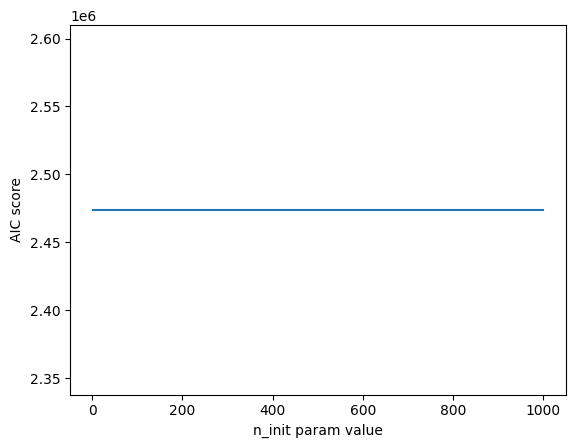

In [99]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

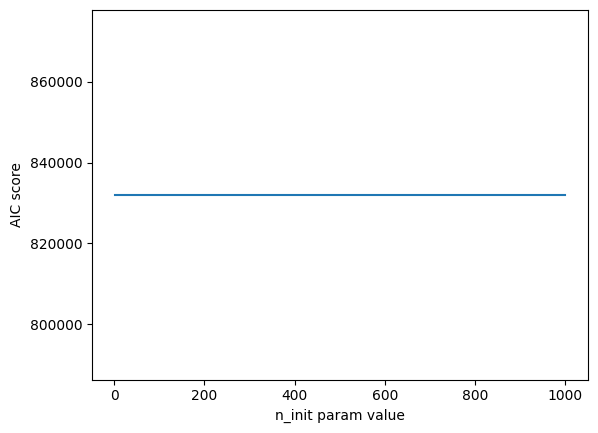

In [100]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

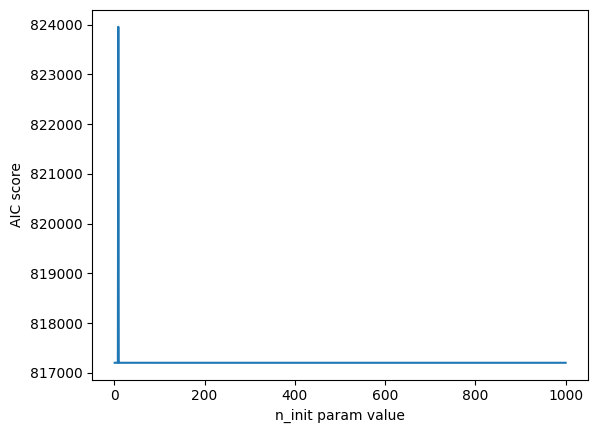

In [101]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [102]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    1.5s remaining:    3.6s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    1.5s remaining:    1.5s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    1.6s remaining:    0.6s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    1.6s finished


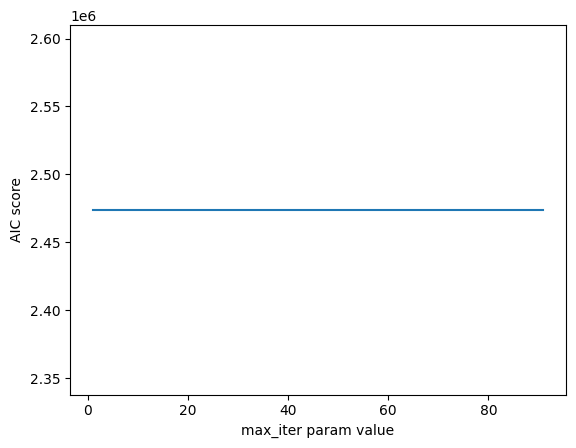

In [103]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

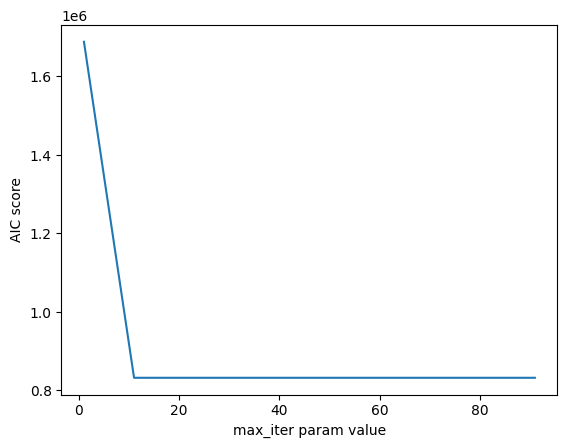

In [104]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

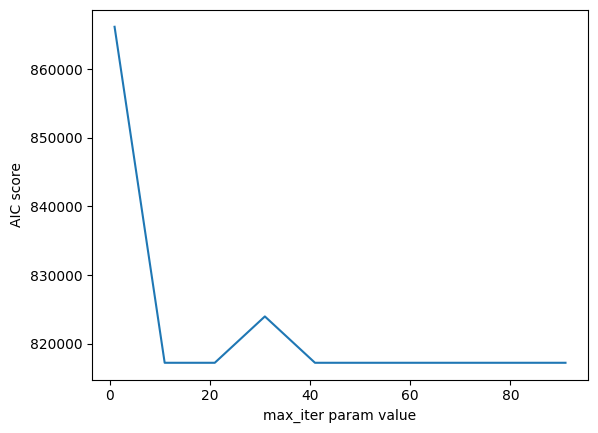

In [105]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [106]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [107]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [108]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [109]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [110]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1949132.931385819
Cluster=1 var: 0.0
Cluster=2 mean: 839257.4909581179
Cluster=2 var: 7.95585906182561e-14
Mean difference: 1109875.4404277012
T-statistic: 39151490302677.77
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [111]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1949132.931385819
Cluster=1 var: 0.0
Cluster=3 mean: 830602.0206067379
Cluster=3 var: 678362.0383075732
Mean difference: 1118530.9107790813
T-statistic: 13512.47238679143
P-value: 0.0


In [112]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 839257.4909581179
Cluster=2 var: 7.95585906182561e-14
Cluster=3 mean: 830602.0206067379
Cluster=3 var: 678362.0383075732
Mean difference: 8655.470351379947
T-statistic: 104.56287170128402
P-value: 3.298864149045904e-175


Class 8

In [113]:
import pandas as pd
#filtering by class
class_num = 8
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 5)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 76745.0, Lower bound: 5985.0


In [114]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


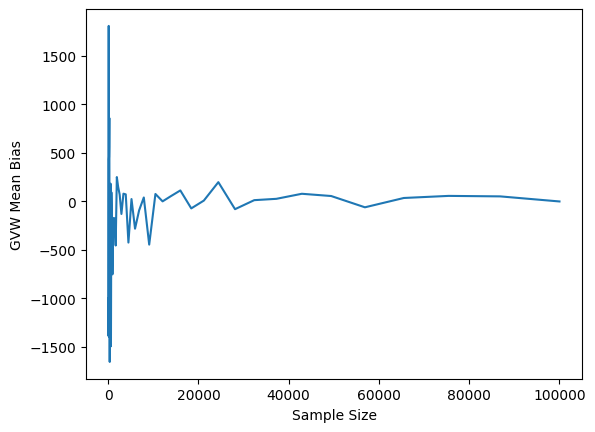

In [115]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [116]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [117]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [118]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    3.9s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    9.2s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   18.4s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   39.2s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:  1.6min
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  3.2min remaining:  1.3min
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  6.0min remaining:  1.3min
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  8.3min remaining:   35.6s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed: 10.4min finished


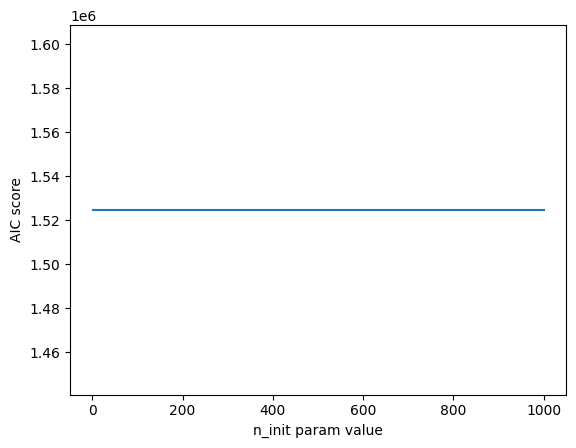

In [119]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

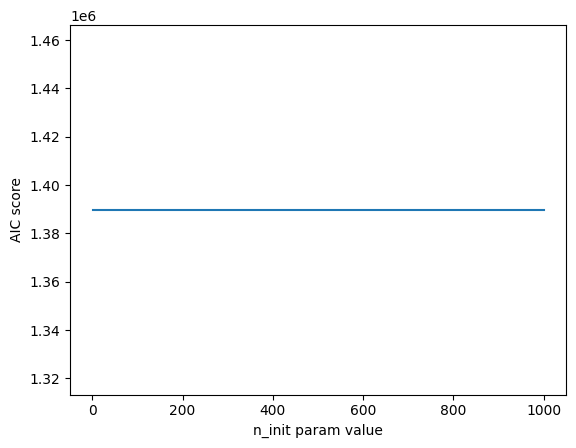

In [120]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

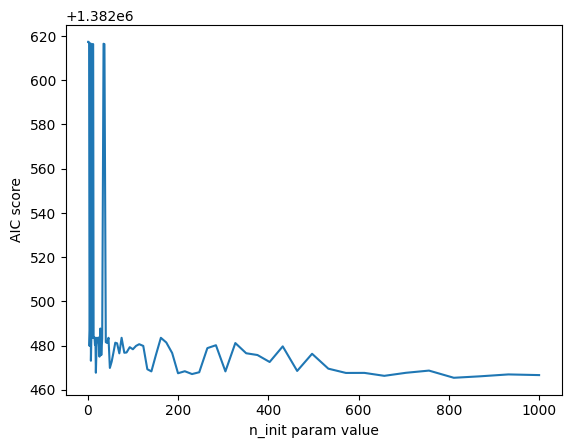

In [121]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [122]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    1.4s remaining:    3.4s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    1.6s remaining:    1.6s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    1.6s remaining:    0.6s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    1.7s finished


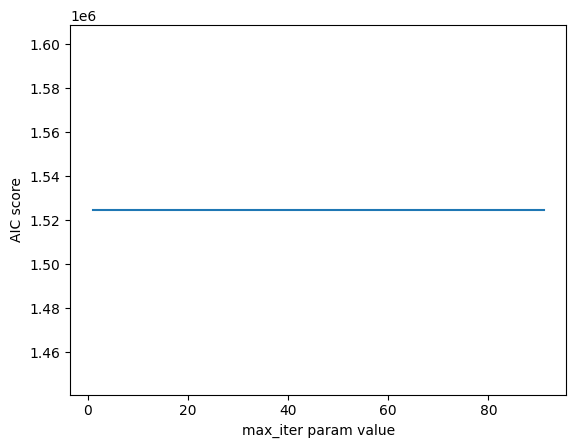

In [123]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

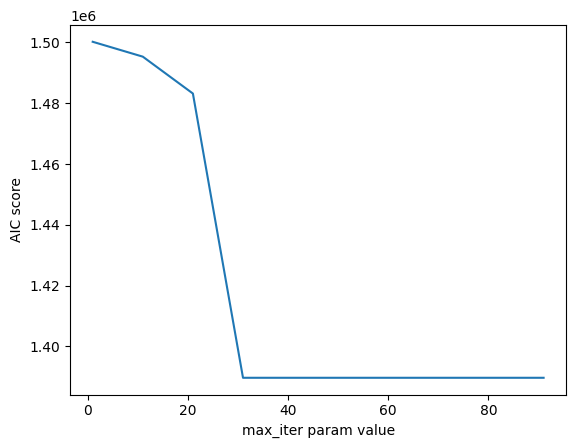

In [124]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

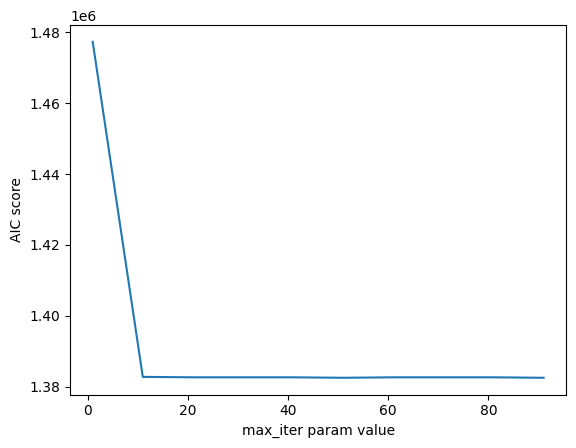

In [125]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [126]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [127]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [128]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [129]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [130]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1505842.2107705108
Cluster=1 var: 2.168404344971009e-19
Cluster=2 mean: 1480904.118249921
Cluster=2 var: 0.004701757843678558
Mean difference: 24938.09252058994
T-statistic: 3618684.333985287
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [131]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1505842.2107705108
Cluster=1 var: 2.168404344971009e-19
Cluster=3 mean: 1458616.9201593392
Cluster=3 var: 1.1468525771789752e-05
Mean difference: 47225.29061117163
T-statistic: 138751740.30377647
P-value: 0.0


In [132]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 1480904.118249921
Cluster=2 var: 0.004701757843678558
Cluster=3 mean: 1458616.9201593392
Cluster=3 var: 1.1468525771789752e-05
Mean difference: 22287.19809058169
T-statistic: 3230084.7772502936
P-value: 0.0


Class 9

In [133]:
import pandas as pd
#filtering by class
class_num = 9
sample_ratio = .01
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 121400.0, Lower bound: -1800.0


In [134]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


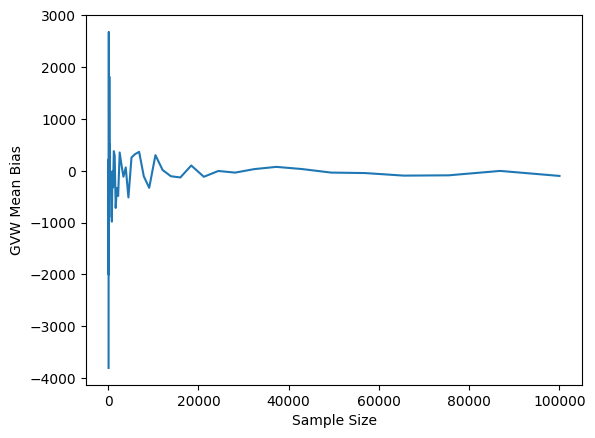

In [135]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [136]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [137]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [138]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    4.6s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:   12.8s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   27.8s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   59.3s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:  2.2min
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  5.0min remaining:  2.0min
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  9.4min remaining:  2.0min
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed: 12.9min remaining:   55.0s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed: 15.9min finished


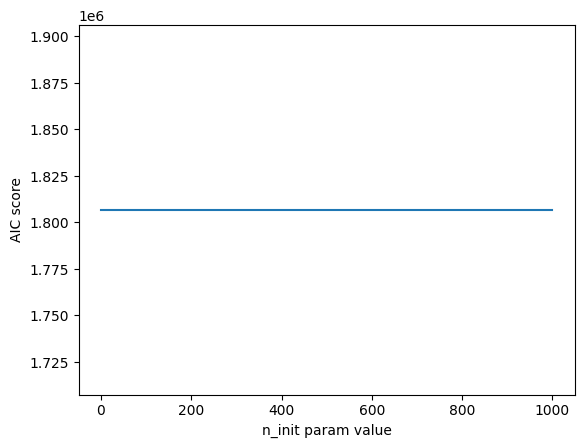

In [139]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

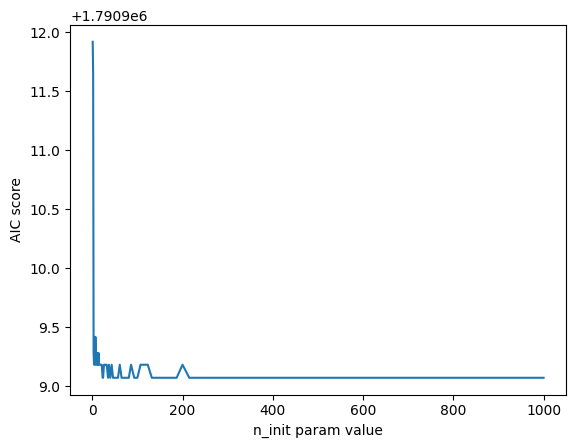

In [140]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

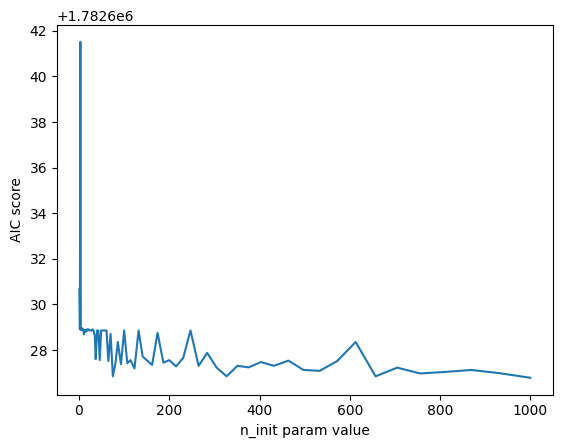

In [141]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [142]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    2.2s remaining:    5.4s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    2.6s remaining:    2.6s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    2.7s remaining:    1.1s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    2.9s finished


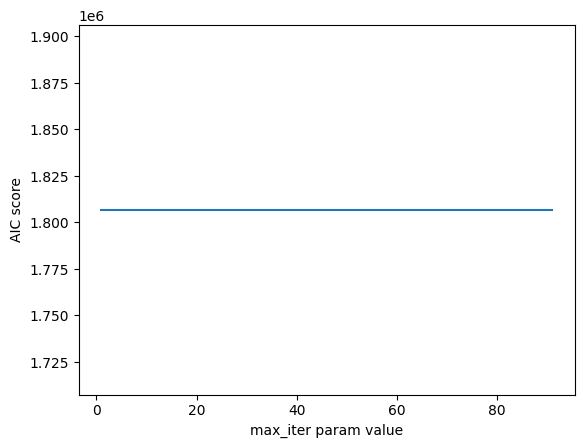

In [143]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

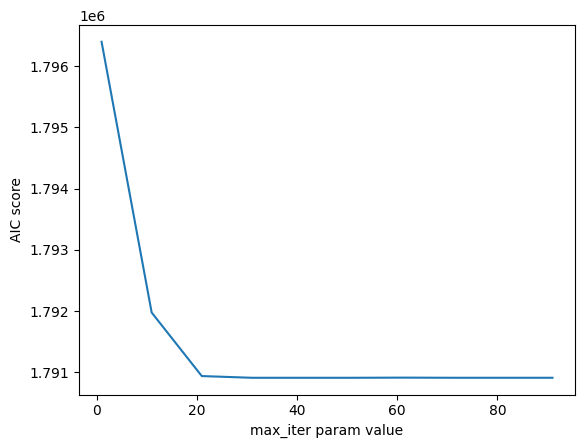

In [144]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

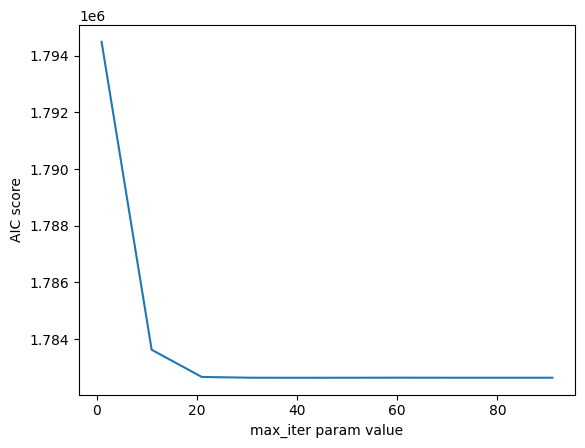

In [145]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [146]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [147]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [148]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [149]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [150]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1804902.5689359857
Cluster=1 var: 4.87890977618477e-19
Cluster=2 mean: 1776032.2209965247
Cluster=2 var: 0.0001948507530664974
Mean difference: 28870.347939461004
T-statistic: 20578730.086219847
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [151]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1804902.5689359857
Cluster=1 var: 4.87890977618477e-19
Cluster=3 mean: 1757345.205802938
Cluster=3 var: 0.00016449041800641382
Mean difference: 47557.36313304771
T-statistic: 36894791.626239434
P-value: 0.0


In [152]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 1776032.2209965247
Cluster=2 var: 0.0001948507530664974
Cluster=3 mean: 1757345.205802938
Cluster=3 var: 0.00016449041800641382
Mean difference: 18687.015193586703
T-statistic: 9808532.75209947
P-value: 0.0


Class 10

In [153]:
import pandas as pd
#filtering by class
class_num = 10
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 18)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 175600.0, Lower bound: 3280.0


In [154]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


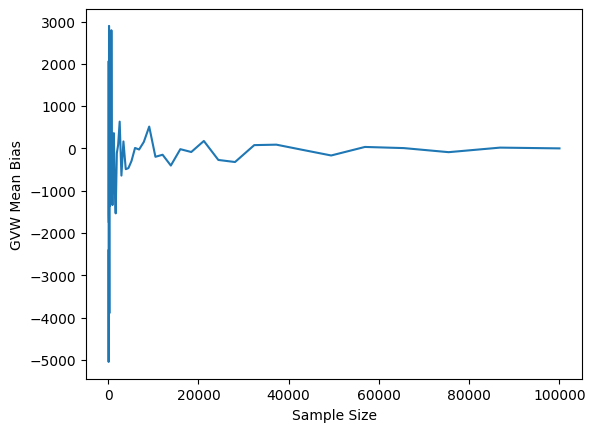

In [155]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [156]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [157]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [158]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    6.2s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:   19.4s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   42.8s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:  1.7min
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:  3.7min
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  9.0min remaining:  3.5min
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed: 15.6min remaining:  3.3min
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed: 21.7min remaining:  1.5min
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed: 23.6min finished


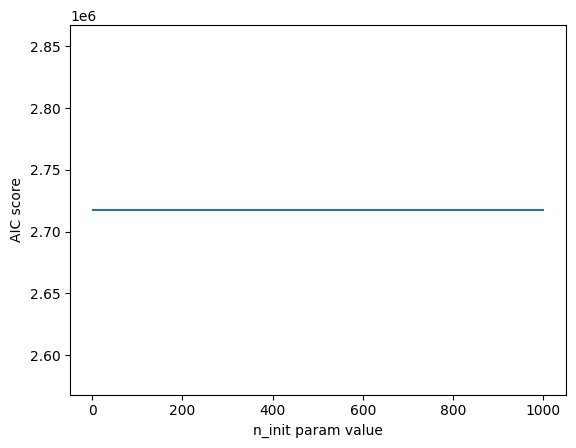

In [159]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

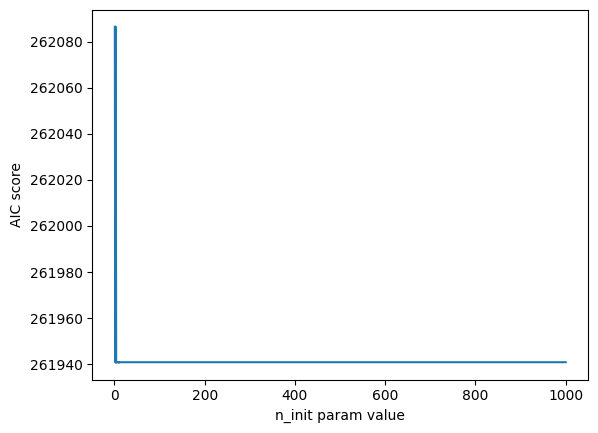

In [160]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

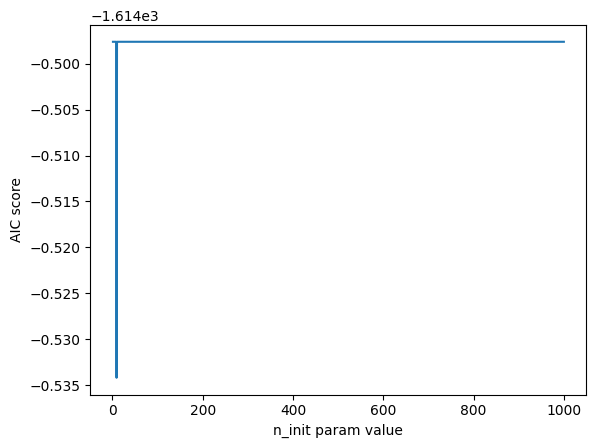

In [161]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [162]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    4.2s remaining:   10.0s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    4.3s remaining:    4.3s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    4.3s remaining:    1.8s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    4.4s finished


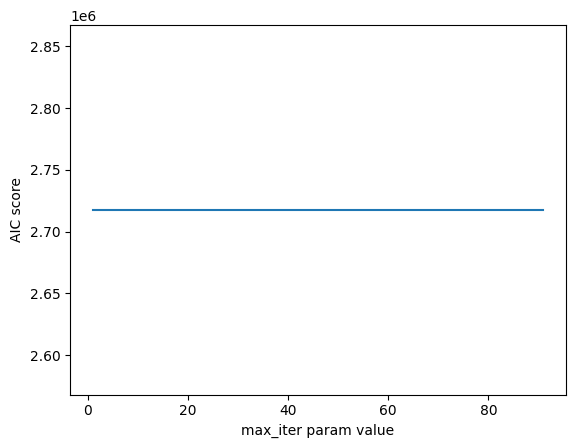

In [163]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

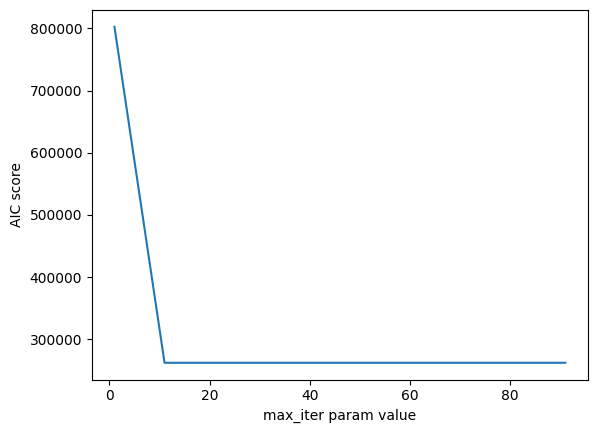

In [164]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

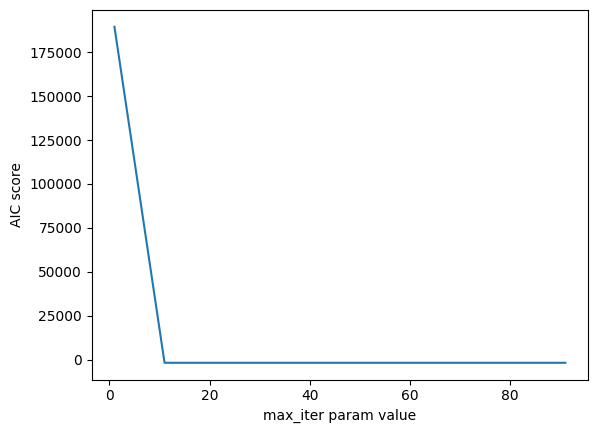

In [165]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [166]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [167]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [168]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [169]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [170]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1657712.9020506088
Cluster=1 var: 2.168404344971009e-19
Cluster=2 mean: 381170.60257690743
Cluster=2 var: 1.0893040270427469e-05
Mean difference: 1276542.2994737013
T-statistic: 3848382692.955068
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [171]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1657712.9020506088
Cluster=1 var: 2.168404344971009e-19
Cluster=3 mean: -137116.14099564485
Cluster=3 var: 4.603470261359617e-05
Mean difference: 1794829.0430462537
T-statistic: 2632073512.8125505
P-value: 0.0


In [172]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 381170.60257690743
Cluster=2 var: 1.0893040270427469e-05
Cluster=3 mean: -137116.14099564485
Cluster=3 var: 4.603470261359617e-05
Mean difference: 518286.7435725523
T-statistic: 683479850.4060811
P-value: 0.0


Class 11

In [173]:
import pandas as pd
#filtering by class
class_num = 11
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.7
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 109110.0, Lower bound: 20670.0


In [174]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


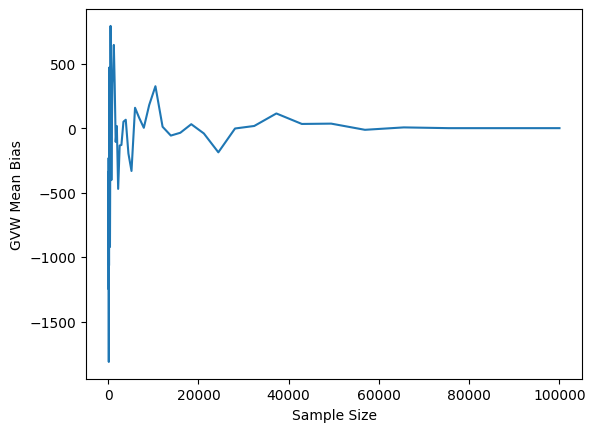

In [175]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [176]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [177]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [178]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    3.7s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:    9.0s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   16.7s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   38.3s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:  1.3min
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  2.9min remaining:  1.1min
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  4.9min remaining:  1.0min
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  7.1min remaining:   30.3s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed:  9.1min finished


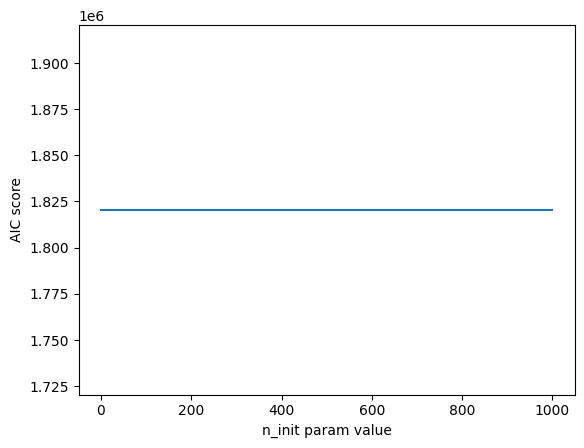

In [179]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

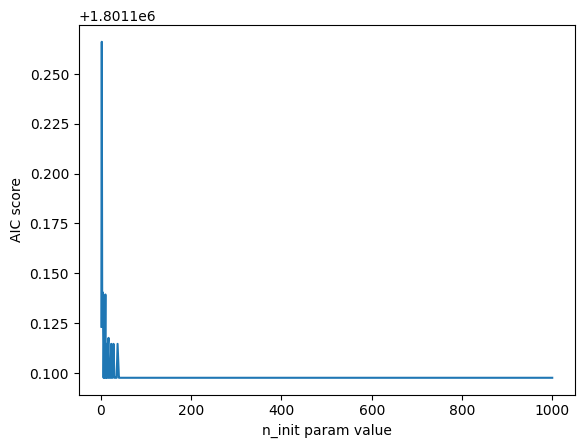

In [180]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

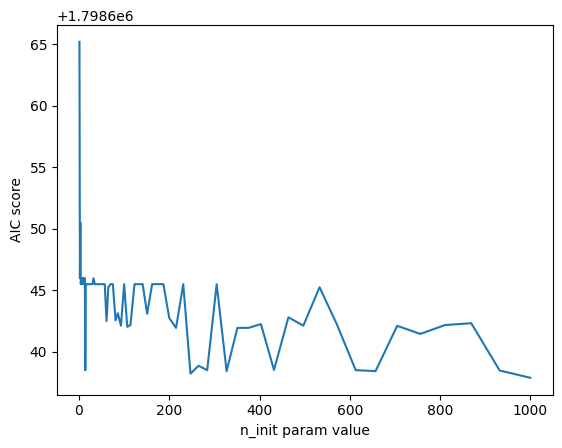

In [181]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [182]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    1.4s remaining:    3.5s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    1.5s remaining:    1.5s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    1.5s remaining:    0.6s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    1.6s finished


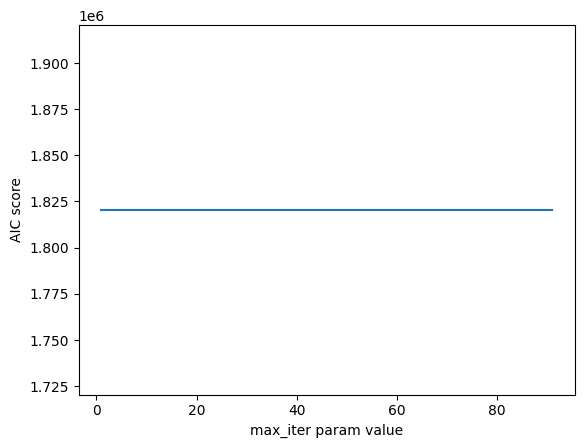

In [183]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

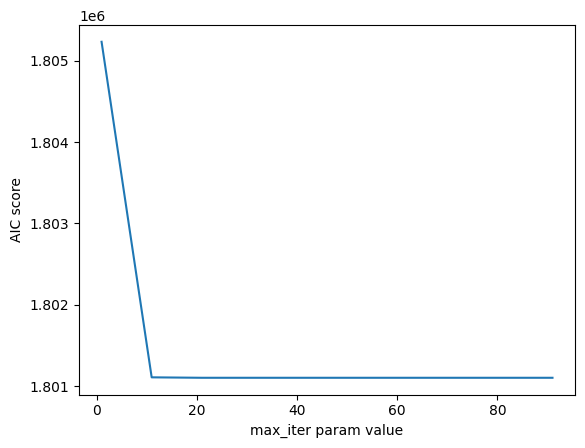

In [184]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

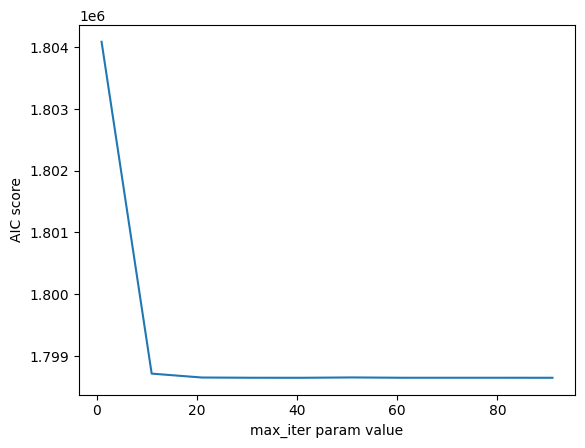

In [185]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [186]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [187]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [188]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [189]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [190]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1817773.0205801686
Cluster=1 var: 0.0
Cluster=2 mean: 1801772.6113100874
Cluster=2 var: 1.4768057461248582e-06
Mean difference: 16000.409270081203
T-statistic: 131004737.74188358
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [191]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 1817773.0205801686
Cluster=1 var: 0.0
Cluster=3 mean: 1798705.6225787476
Cluster=3 var: 0.5970549478193092
Mean difference: 19067.39800142101
T-statistic: 245528.48173778565
P-value: 0.0


In [192]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 1801772.6113100874
Cluster=2 var: 1.4768057461248582e-06
Cluster=3 mean: 1798705.6225787476
Cluster=3 var: 0.5970549478193092
Mean difference: 3066.9887313398067
T-statistic: 39493.17863668624
P-value: 0.0


Class 12

In [193]:
import pandas as pd
#filtering by class
class_num = 12
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 7)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 2.0
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 100380.0, Lower bound: 19980.0


In [194]:
#Check the bias of the sample mean as the sample size increases
#Goal : minimize sample size, mean bias 
import numpy as np
from pyspark.sql import functions as F

total_count = df_spark.count()
pop_mean_gvw = df_spark.select(F.mean("gvw")).first()[0]

sample_size_container = []
bias_container = []

max_sample_size = 100000
sample_range = np.logspace(np.log10(100), np.log10(100000), num=50, dtype=int)
sample_range = np.unique(sample_range)

counter = 1
for sample_size in sample_range:
    bias, size = find_sample_mean(df_spark, pop_mean_gvw, sample_size, total_count)
    bias_container.append(bias)
    sample_size_container.append(size)
    print(f"Trial {counter}/{len(sample_range)}")
    counter +=1
   


Trial 1/50
Trial 2/50
Trial 3/50
Trial 4/50
Trial 5/50
Trial 6/50
Trial 7/50
Trial 8/50
Trial 9/50
Trial 10/50
Trial 11/50
Trial 12/50
Trial 13/50
Trial 14/50
Trial 15/50
Trial 16/50
Trial 17/50
Trial 18/50
Trial 19/50
Trial 20/50
Trial 21/50
Trial 22/50
Trial 23/50
Trial 24/50
Trial 25/50
Trial 26/50
Trial 27/50
Trial 28/50
Trial 29/50
Trial 30/50
Trial 31/50
Trial 32/50
Trial 33/50
Trial 34/50
Trial 35/50
Trial 36/50
Trial 37/50
Trial 38/50
Trial 39/50
Trial 40/50
Trial 41/50
Trial 42/50
Trial 43/50
Trial 44/50
Trial 45/50
Trial 46/50
Trial 47/50
Trial 48/50
Trial 49/50
Trial 50/50


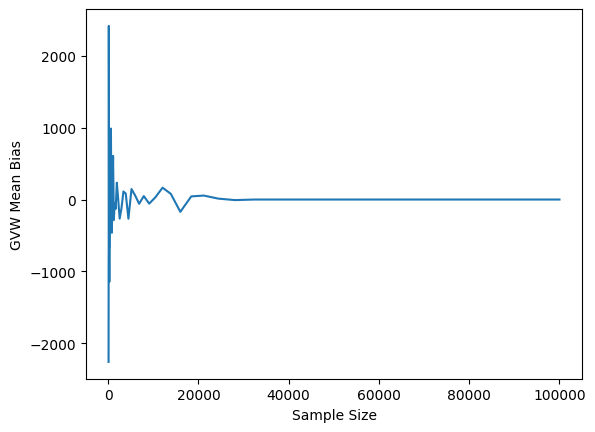

In [195]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_size_container, bias_container)
plt.xlabel("Sample Size")
plt.ylabel("GVW Mean Bias")
plt.show()

In [196]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [197]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [198]:
#Tuning n_init parameter for stability
import os
from joblib import Parallel, delayed
import numpy as np

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 1000
sample_range = np.logspace(np.log10(1), np.log10(number_of_trials), num=100, dtype=int)
sample_range = np.unique(sample_range)

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, n, 100) 
    for n in sample_range
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:    4.0s
[Parallel(n_jobs=15)]: Done  11 tasks      | elapsed:   11.3s
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:   21.1s
[Parallel(n_jobs=15)]: Done  31 tasks      | elapsed:   44.6s
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:  1.6min
[Parallel(n_jobs=15)]: Done  54 out of  75 | elapsed:  3.7min remaining:  1.4min
[Parallel(n_jobs=15)]: Done  62 out of  75 | elapsed:  6.3min remaining:  1.3min
[Parallel(n_jobs=15)]: Done  70 out of  75 | elapsed:  9.1min remaining:   39.1s
[Parallel(n_jobs=15)]: Done  75 out of  75 | elapsed: 10.3min finished


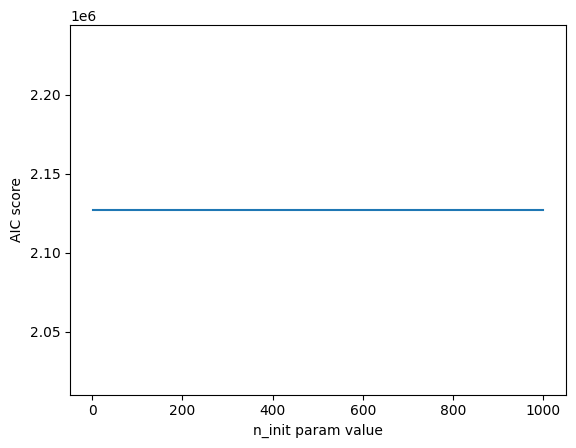

In [199]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(sample_range, aic_n1)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

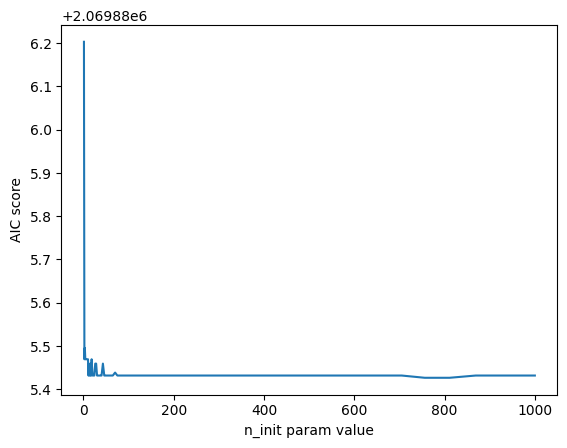

In [200]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(sample_range, aic_n2)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

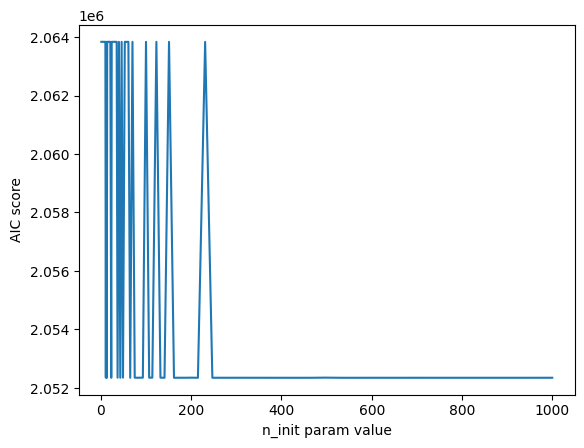

In [201]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(sample_range, aic_n3)
plt.xlabel("n_init param value")
plt.ylabel("AIC score")
plt.show()

In [202]:
#Tuning max_iter parameter
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

aic_n1 = []
aic_n2 = []
aic_n3 = []
number_of_trials = 100

results = Parallel(n_jobs=num_of_cores-1, verbose=10)(
    delayed(tune_parameter)(tuning_sample_df, cols, 5, n) 
    for n in range(1, number_of_trials+1, 10)
)

# Results are returned in order
for aic1, aic2, aic3 in results:
    aic_n1.append(aic1)
    aic_n2.append(aic2)
    aic_n3.append(aic3)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  10 | elapsed:    1.7s remaining:    4.0s
[Parallel(n_jobs=15)]: Done   5 out of  10 | elapsed:    1.7s remaining:    1.7s
[Parallel(n_jobs=15)]: Done   7 out of  10 | elapsed:    1.8s remaining:    0.7s
[Parallel(n_jobs=15)]: Done  10 out of  10 | elapsed:    1.8s finished


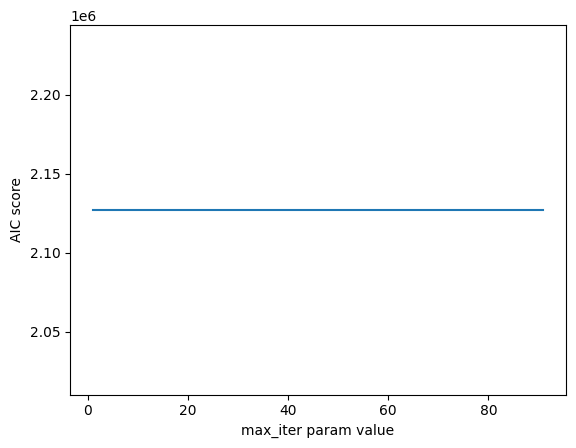

In [203]:
import matplotlib.pyplot as plt
import numpy as np

#1 clusters results
plt.plot(np.arange(1,101,10), aic_n1)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

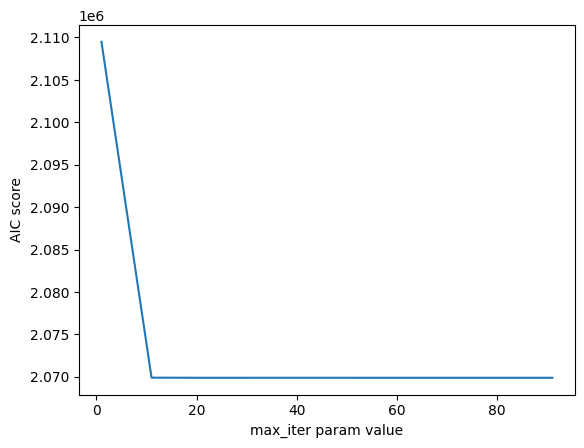

In [204]:
import matplotlib.pyplot as plt
import numpy as np

#2 clusters results
plt.plot(np.arange(1,101,10), aic_n2)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

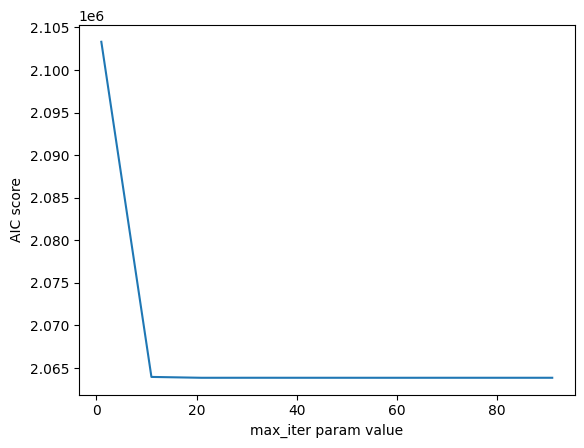

In [205]:
import matplotlib.pyplot as plt
import numpy as np

#3 clusters results
plt.plot(np.arange(1,101,10), aic_n3)
plt.xlabel("max_iter param value")
plt.ylabel("AIC score")
plt.show()

In [206]:
#Tuned Params
"""  

Sample size : 20,000

Clusters 1:
n_init : 10
max_iter : 20

Clusters 2:
n_init : 10
max_iter : 20

Clusters 3:
n_init : 200  
max_iter : 20

"""

'  \n\nSample size : 20,000\n\nClusters 1:\nn_init : 10\nmax_iter : 20\n\nClusters 2:\nn_init : 10\nmax_iter : 20\n\nClusters 3:\nn_init : 200  \nmax_iter : 20\n\n'

In [207]:
import os
from joblib import Parallel, delayed

num_of_cores = os.cpu_count() #number of cpu cores in system

#cluster 1
#Computing mean of sample means of AIC score 
cluster_num = 1
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n1_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n1_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [208]:
#cluster 2
#Computing mean of sample means of AIC score 

cluster_num = 2
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n2_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n2_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [209]:
#cluster 3
#Computing mean of sample means of AIC score 

cluster_num = 3
num_of_sample_means = 100
num_of_trials_in_sample_mean = 100

sample_size = 20000
n_init = 10
max_iter = 20

n3_sample_means = []

for i in range(1,num_of_sample_means+1):
    df_sample = df_spark.filter(f"class = {class_num}") \
    .sample(withReplacement=False, fraction=1.0) \
    .limit(sample_size) \
    .toPandas()

    results = Parallel(n_jobs=num_of_cores-1, verbose=0)(
        delayed(fit_gaussian_model_pandas)(df_sample, cols, cluster_num, n_init, max_iter) 
        for n in range(1, num_of_trials_in_sample_mean+1)
    )

    AIC_score = []
    # Results are returned in order
    for aic in results:
        AIC_score.append(aic)

    n3_sample_means.append(np.mean(AIC_score))
    print(f"Sample mean computed {i}/{num_of_sample_means}")

    del df_sample, results, AIC_score
    gc.collect()  # Force garbage collection

Sample mean computed 1/100
Sample mean computed 2/100
Sample mean computed 3/100
Sample mean computed 4/100
Sample mean computed 5/100
Sample mean computed 6/100
Sample mean computed 7/100
Sample mean computed 8/100
Sample mean computed 9/100
Sample mean computed 10/100
Sample mean computed 11/100
Sample mean computed 12/100
Sample mean computed 13/100
Sample mean computed 14/100
Sample mean computed 15/100
Sample mean computed 16/100
Sample mean computed 17/100
Sample mean computed 18/100
Sample mean computed 19/100
Sample mean computed 20/100
Sample mean computed 21/100
Sample mean computed 22/100
Sample mean computed 23/100
Sample mean computed 24/100
Sample mean computed 25/100
Sample mean computed 26/100
Sample mean computed 27/100
Sample mean computed 28/100
Sample mean computed 29/100
Sample mean computed 30/100
Sample mean computed 31/100
Sample mean computed 32/100
Sample mean computed 33/100
Sample mean computed 34/100
Sample mean computed 35/100
Sample mean computed 36/100
S

In [210]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n2_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n2_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 2142945.472348429
Cluster=1 var: 0.0
Cluster=2 mean: 2076000.8471724943
Cluster=2 var: 3.560605328479699e-05
Mean difference: 66944.62517593452
T-statistic: 111627549.97638625
P-value: 0.0


c:\Users\rubie\anaconda3\envs\Fall25_Capstone\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [211]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n1_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=1 mean: {np.mean(n1_sample_means)}")
print(f"Cluster=1 var: {np.var(n1_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n1_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=1 mean: 2142945.472348429
Cluster=1 var: 0.0
Cluster=3 mean: 2066566.2200443582
Cluster=3 var: 274601.6050105279
Mean difference: 76379.25230407063
T-statistic: 1450.2452920507862
P-value: 0.0


In [212]:
#T-test to check if the mean of cluster=2 are significantly different from cluster=3
import numpy as np
from scipy import stats
t_stat, p_value = stats.ttest_ind(n2_sample_means, n3_sample_means)

#AIC sample means dist.
print(f"Cluster=2 mean: {np.mean(n2_sample_means)}")
print(f"Cluster=2 var: {np.var(n2_sample_means)}")
print(f"Cluster=3 mean: {np.mean(n3_sample_means)}")
print(f"Cluster=3 var: {np.var(n3_sample_means)}")
print(f"Mean difference: {np.mean(n2_sample_means) - np.mean(n3_sample_means)}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Cluster=2 mean: 2076000.8471724943
Cluster=2 var: 3.560605328479699e-05
Cluster=3 mean: 2066566.2200443582
Cluster=3 var: 274601.6050105279
Mean difference: 9434.627128136111
T-statistic: 179.1392709564106
P-value: 5.345548201063642e-221


Class 13

In [213]:
import pandas as pd
#filtering by class
class_num = 13
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 165510.0, Lower bound: -56010.0


In [216]:
#Sample original dataset
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).toPandas()

In [217]:
#Sub-sample for model parameter tuning
sample_size = min(20000, df_sample.shape[0])
tuning_sample_df = df_sample.sample(sample_size)

In [233]:
cov_matrix = np.cov(tuning_sample_df[cols], rowvar=False)

# Step 2: Eigendecomposition
eigvals, eigvecs = np.linalg.eigh(cov_matrix)  # use eigh (for symmetric matrices)
eig_df = pd.DataFrame(
    eigvecs,
    index=cols,
    columns=[f"PC{i+1}" for i in range(len(cols))]
)
print("Eigenvectors:\n", eig_df)
print("\nEigenvalues:\n", eigvals)


Eigenvectors:
           PC1       PC2       PC3       PC4       PC5
wt1 -0.062323  0.125498 -0.956357 -0.247259 -0.067900
wt2  0.015031 -0.648092  0.067318 -0.419616 -0.631776
wt3 -0.003768  0.734301  0.179129 -0.143780 -0.638771
wt4 -0.028121 -0.157400 -0.210719  0.861336 -0.433743
wt5  0.997539  0.015943 -0.066028  0.014613 -0.009363

Eigenvalues:
 [3.55317557e+07 1.05217252e+08 2.12106614e+08 6.75065935e+08
 4.12213636e+09]


In [235]:
tuning_sample_df[cols].describe()

,wt1,wt2,wt3,wt4,wt5
count,6733.000000,6.733000e+03,6.733000e+03,6.733000e+03,6733.00000
mean,8371.887717,1.214166e+04,1.202213e+04,1.059813e+04,10249.59899
std,16002.124280,4.253633e+04,4.194572e+04,3.589419e+04,6067.46303
min,0.000000,1.400000e+02,0.000000e+00,0.000000e+00,0.00000
25%,4540.000000,4.080000e+03,4.310000e+03,4.120000e+03,4330.00000
50%,9080.000000,1.140000e+04,1.132000e+04,9.410000e+03,10030.00000
75%,10660.000000,1.631000e+04,1.629000e+04,1.474000e+04,15400.00000
max,988340.000000,2.188830e+06,2.222990e+06,2.676470e+06,34040.00000


In [238]:
tuning_sample_df[cols].corr()

,wt1,wt2,wt3,wt4,wt5
wt1,1.000000,0.330003,0.262440,0.031963,0.119234
wt2,0.330003,1.000000,0.928554,0.585078,0.072640
wt3,0.262440,0.928554,1.000000,0.689637,0.085755
wt4,0.031963,0.585078,0.689637,1.000000,0.123644
wt5,0.119234,0.072640,0.085755,0.123644,1.000000


In [242]:
fit_gaussian_model_pandas(tuning_sample_df, cols, 1, 10, 20)

np.float64(752039.8542724391)

In [241]:
fit_gaussian_model_pandas(tuning_sample_df, cols, 2, 10, 20)

ValueError: Fitting the mixture model failed because some components have ill-defined empirical covariance (for instance caused by singleton or collapsed samples). Try to decrease the number of components, or increase reg_covar.

Analyzing Performance Difference For Cluster = 2 vs 3

In [32]:
import numpy as np
def format_print_cluster_info(means_array):
    for row in range(means_array.shape[0]):
        mean_str = ""
        for col in range(means_array.shape[1]):
            mean_str += f"{means_array[row, col]:.2f}, "
        print(f"Cluster {row+1} centroid: ({mean_str[:-2]}), GVW: {np.sum(means_array[row,:]):.2f}")

In [39]:
#Gaussian Model
from sklearn.mixture import GaussianMixture as GM

def print_cluster_mean_wts(data, cols, n_components, n_init=20, max_iter=100):
    input = data[cols]
    model = GM(n_components=n_components, n_init=n_init, max_iter=max_iter).fit(input)

    format_print_cluster_info(model.means_)

    print("\nCluster Weights")
    print(model.weights_)   # shape (n_components, n_features)

Class 2

In [13]:
import pandas as pd
#filtering by class
class_num = 2
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.6
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 6664.0, Lower bound: 196.0


In [14]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [43]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (2255.09, 1845.39, 0.09, 0.00, 0.00), GVW: 4100.58

Cluster Weights
[1.]


In [42]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (2255.12, 1845.35, 0.00, 0.00, 0.00), GVW: 4100.47
Cluster 2 centroid: (1950.00, 2310.00, 940.00, 0.00, 0.00), GVW: 5200.00

Cluster Weights
[9.999e-01 1.000e-04]


In [41]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (1950.00, 2310.00, 940.00, 0.00, 0.00), GVW: 5200.00
Cluster 2 centroid: (2543.37, 2276.72, 0.00, 0.00, 0.00), GVW: 4820.09
Cluster 3 centroid: (2068.92, 1566.68, 0.00, 0.00, 0.00), GVW: 3635.60

Cluster Weights
[1.00000000e-04 3.92427472e-01 6.07472528e-01]


Class 3

In [44]:
import pandas as pd
#filtering by class
class_num = 3
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 2.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 12790.0, Lower bound: -1970.0


In [45]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [46]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (3075.35, 2928.91, 11.59, 5.28, 0.00), GVW: 6021.13

Cluster Weights
[1.]


In [47]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (3072.74, 2921.57, 0.00, 0.00, 0.00), GVW: 5994.30
Cluster 2 centroid: (3435.92, 3939.64, 1607.63, 732.46, 0.00), GVW: 9715.65

Cluster Weights
[0.99279 0.00721]


In [48]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (3927.58, 4971.52, 0.00, 0.00, 0.00), GVW: 8899.11
Cluster 2 centroid: (3007.63, 2764.67, 0.00, 0.00, 0.00), GVW: 5772.30
Cluster 3 centroid: (3394.75, 3945.11, 1644.11, 749.08, 0.00), GVW: 9733.05

Cluster Weights
[0.07064996 0.92230004 0.00705   ]


Class 4

In [49]:
import pandas as pd
#filtering by class
class_num = 4
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.3
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 63208.0, Lower bound: -9368.0


In [50]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [51]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (9478.80, 13153.72, 4325.81, 0.00, 0.00), GVW: 26958.33

Cluster Weights
[1.]


In [52]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (9771.09, 13779.57, 9184.32, 0.00, 0.00), GVW: 32734.98
Cluster 2 centroid: (9218.56, 12596.49, 0.00, 0.00, 0.00), GVW: 21815.04

Cluster Weights
[0.471 0.529]


In [53]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (9187.42, 13621.62, 8825.44, 0.00, 0.00), GVW: 31634.48
Cluster 2 centroid: (17671.23, 14669.61, 11373.38, 0.00, 0.00), GVW: 43714.23
Cluster 3 centroid: (8954.89, 12631.10, 0.00, 0.00, 0.00), GVW: 21585.99

Cluster Weights
[0.42738606 0.04870503 0.52390891]


Class 5

In [54]:
import pandas as pd
#filtering by class
class_num = 5
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.6
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 44052.0, Lower bound: -9162.0


In [55]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [56]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (6115.74, 8688.08, 129.07, 23.90, 2.50), GVW: 14959.30

Cluster Weights
[1.]


In [57]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (6119.72, 8692.33, 105.84, 0.00, 0.00), GVW: 14917.89
Cluster 2 centroid: (5493.86, 8023.78, 3763.46, 3763.78, 394.17), GVW: 21439.06

Cluster Weights
[0.99365 0.00635]


In [58]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (8394.89, 10603.32, 6495.90, 1098.39, 0.00), GVW: 26592.50
Cluster 2 centroid: (4717.86, 5301.43, 2062.14, 1831.43, 1787.86), GVW: 15700.71
Cluster 3 centroid: (6072.53, 8654.93, 0.00, 0.00, 0.00), GVW: 14727.46

Cluster Weights
[0.01942473 0.0014     0.97917527]


Class 6

In [59]:
import pandas as pd
#filtering by class
class_num = 6
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.6
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 74704.0, Lower bound: -2534.0


In [60]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [61]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (11676.50, 10758.34, 11012.82, 0.00, 0.00), GVW: 33447.66

Cluster Weights
[1.]


In [62]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (11482.13, 9982.56, 10258.54, 0.00, 0.00), GVW: 31723.23
Cluster 2 centroid: (13292.47, 17208.22, 17284.01, 0.00, 0.00), GVW: 47784.70

Cluster Weights
[0.89263585 0.10736415]


In [63]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (12857.33, 12849.48, 13312.37, 0.00, 0.00), GVW: 39019.18
Cluster 2 centroid: (9562.34, 6499.83, 6479.50, 0.00, 0.00), GVW: 22541.67
Cluster 3 centroid: (11972.68, 15851.74, 15285.39, 0.00, 0.00), GVW: 43109.81

Cluster Weights
[0.61296955 0.34785463 0.03917581]


Class 7

In [64]:
import pandas as pd
#filtering by class
class_num = 7
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 8)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 115145.0, Lower bound: -1535.0


In [65]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [66]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (12603.14, 9465.98, 13941.11, 14829.57, 108.95, 8.32, 0.00), GVW: 50957.06

Cluster Weights
[1.]


In [67]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (12578.72, 9467.18, 13971.83, 14828.08, 0.00, 0.00, 0.00), GVW: 50845.82
Cluster 2 centroid: (15895.47, 9303.28, 9798.27, 15029.72, 14802.34, 1130.39, 0.00), GVW: 65959.47

Cluster Weights
[0.99263968 0.00736032]


In [68]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (12543.53, 9402.49, 13928.18, 14877.23, 0.00, 0.00, 0.00), GVW: 50751.43
Cluster 2 centroid: (14680.00, 7470.91, 9385.45, 9536.36, 15176.36, 15127.27, 0.00), GVW: 71376.36
Cluster 3 centroid: (16842.65, 14151.44, 15062.98, 11586.98, 7401.56, 0.00, 0.00), GVW: 65045.61

Cluster Weights
[9.85857857e-01 5.50000000e-04 1.35921429e-02]


Class 8

In [69]:
import pandas as pd
#filtering by class
class_num = 8
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 5)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 76745.0, Lower bound: 5985.0


In [70]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [71]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (8832.58, 11443.41, 6990.71, 7376.99), GVW: 34643.70

Cluster Weights
[1.]


In [72]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (8848.72, 14820.62, 8838.71, 4440.47), GVW: 36948.51
Cluster 2 centroid: (8830.09, 10922.60, 6705.73, 7829.85), GVW: 34288.26

Cluster Weights
[0.13361014 0.86638986]


In [73]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (10370.50, 8432.37, 8350.27, 10871.84), GVW: 38024.97
Cluster 2 centroid: (8686.49, 14774.26, 8462.13, 4394.41), GVW: 36317.30
Cluster 3 centroid: (8392.92, 11628.93, 6247.08, 6965.74), GVW: 33234.67

Cluster Weights
[0.20078438 0.14507417 0.65414145]


Class 9

In [74]:
import pandas as pd
#filtering by class
class_num = 9
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 121400.0, Lower bound: -1800.0


In [75]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [76]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (10130.55, 10546.16, 10420.14, 9343.86, 9992.17), GVW: 50432.87

Cluster Weights
[1.]


In [77]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (9745.83, 7612.23, 7564.87, 6174.02, 6778.72), GVW: 37875.67
Cluster 2 centroid: (10663.59, 14611.25, 14376.25, 13735.83, 14444.54), GVW: 67831.47

Cluster Weights
[0.58080897 0.41919103]


In [78]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (10869.30, 13109.78, 12993.28, 12216.43, 13000.93), GVW: 62189.72
Cluster 2 centroid: (8442.60, 11992.37, 11393.45, 10278.28, 10889.38), GVW: 52996.07
Cluster 3 centroid: (9402.92, 6548.11, 6503.71, 5002.39, 5461.29), GVW: 32918.41

Cluster Weights
[0.54609701 0.07617857 0.37772442]


Class 10

In [79]:
import pandas as pd
#filtering by class
class_num = 10
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 18)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.5
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 175600.0, Lower bound: 3280.0


In [80]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [81]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (9994.21, 14674.80, 14550.04, 12054.64, 13138.50, 13537.60, 3852.39, 12.73, 0.64, 0.60, 0.54, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00), GVW: 81816.70

Cluster Weights
[1.]


In [82]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (9959.61, 14016.08, 13891.65, 11892.14, 12389.07, 12669.75, 0.66, 0.89, 0.12, 0.10, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00), GVW: 74820.07
Cluster 2 centroid: (10107.07, 16823.18, 16697.31, 12584.64, 15582.69, 16368.02, 16414.52, 51.34, 2.36, 2.23, 2.31, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00), GVW: 104635.67

Cluster Weights
[0.76533648 0.23466352]


In [83]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (9956.40, 14013.07, 13882.86, 11879.96, 12381.20, 12672.20, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00), GVW: 74785.69
Cluster 2 centroid: (10094.32, 16792.31, 16651.65, 12417.06, 15614.81, 16381.23, 16504.96, 2.97, 0.39, 0.34, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00), GVW: 104460.04
Cluster 3 centroid: (10997.60, 18019.50, 19218.59, 20579.09, 14907.15, 15020.30, 10690.42, 2039.97, 93.81, 88.56, 91.78, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00), GVW: 111746.76

Cluster Weights
[0.76451125 0.22958303 0.00590572]


Class 11

In [84]:
import pandas as pd
#filtering by class
class_num = 11
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 6)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 1.7
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 109110.0, Lower bound: 20670.0


In [85]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [86]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (9630.14, 15322.89, 13122.17, 12406.51, 11360.62), GVW: 61842.33

Cluster Weights
[1.]


In [87]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (7312.24, 12257.12, 10740.15, 9041.81, 8304.16), GVW: 47655.49
Cluster 2 centroid: (10156.81, 16019.48, 13663.41, 13171.03, 12055.11), GVW: 65065.84

Cluster Weights
[0.18514939 0.81485061]


In [88]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (10178.03, 14392.01, 11746.59, 10444.94, 9757.99), GVW: 56519.56
Cluster 2 centroid: (6249.87, 10755.04, 9449.28, 8604.50, 7815.45), GVW: 42874.13
Cluster 3 centroid: (10137.25, 17693.25, 15660.40, 15576.05, 14087.75), GVW: 73154.70

Cluster Weights
[0.43427994 0.13500629 0.43071377]


Class 12

In [89]:
import pandas as pd
#filtering by class
class_num = 12
sample_ratio = 1.0
cols = [f"wt{i}" for i in range(1, 7)] #Max number of axles for this class is 5, determined in kmeans notebook

df_spark = df5.filter(f"class = {class_num}")

iqr_factor = 2.0
df_spark = remove_outliers_iqr2(df_spark, iqr_factor)[0]

Upper bound: 100380.0, Lower bound: 19980.0


In [90]:
#sampling 20,000 records to fit
df_sample = df_spark.sample(
    withReplacement=False,  
    fraction=sample_ratio,                          
).limit(20000).toPandas()

In [91]:
print_cluster_mean_wts(df_sample, cols, 1) #1 clusters

Cluster 1 centroid: (9350.88, 8511.84, 8586.56, 11358.96, 11248.96, 9922.18), GVW: 58979.38

Cluster Weights
[1.]


In [92]:
print_cluster_mean_wts(df_sample, cols, 2) #2 clusters

Cluster 1 centroid: (10118.51, 8886.04, 8825.21, 11805.84, 11827.49, 10529.64), GVW: 61992.71
Cluster 2 centroid: (6681.49, 7210.62, 7756.67, 9804.95, 9237.18, 7809.79), GVW: 48500.71

Cluster Weights
[0.77665774 0.22334226]


In [93]:
print_cluster_mean_wts(df_sample, cols, 3) #3 clusters

Cluster 1 centroid: (10180.91, 10616.67, 10523.70, 14303.58, 13389.13, 10118.47), GVW: 69132.46
Cluster 2 centroid: (6051.60, 6304.04, 6999.88, 8871.80, 8214.66, 7646.42), GVW: 44088.40
Cluster 3 centroid: (10068.85, 8792.32, 8733.35, 11600.91, 11731.58, 10465.99), GVW: 61393.00

Cluster Weights
[0.09358452 0.18133409 0.72508139]
